# Исследование объявлений о продаже квартир
<a class="anchor" id="content"></a>

## Содержание

1. [Описание проекта](#desc)
2. [План работы](#plan)
3. [Получение данных](#get)
4. [Предобработка данных](#preproccesing)
5. [Добавление новых признаков](#attribute)
6. [Ход исследования](#research)
7. [Результаты исследования](#result)

<a class="anchor" id="desc"></a>
### 1. Описание проекта

В нашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений за несколько лет о продаже квартир в Санкт-Петербурге и соседних населённых пунктах.

О каждой квартире в базе содержится два типа данных: добавленные пользователем и картографические. Например, к первому типу относятся площадь квартиры, её этаж и количество балконов, ко второму — расстояния до центра города, аэропорта и ближайшего парка. 

#### Цель исследования
Найти интересные особенности и зависимости, которые существуют на рынке недвижимости.

#### Задачи исследования
* выполнить предобработку данных
* добавить в таблицу новые признаки
* как быстро продавались квартиры?
* какие факторы больше всего влияют на полную стоимость квартиры?
* выведите топ-10 населённых пунктов с объявлениями?
* как стоимость объектов зависит от расстояния до центра Санкт-Петербурга в черте города?

#### Описание данных

* `airports_nearest` — расстояние до ближайшего аэропорта в метрах (м)
* `balcony` — число балконов
* `ceiling_height` — высота потолков (м)
* `center_do_nearest` — расстояние до центра города (м)
* `days_exposition` — сколько дней было размещено объявление (от публикации до снятия)
* `first_day_exposition` — дата публикации
* `floor` — этаж
* `floors_total` — всего этажей в доме
* `is_apartment` — апартаменты (булев тип)
* `kitchen_area` — площадь кухни в квадратных метрах (м²)
* `last_price` — цена на момент снятия с публикации
* `living_area` — жилая площадь в квадратных метрах (м²)
* `locality_name` — название населённого пункта
* `open_plan` — свободная планировка (булев тип)
* `parks_around_3000m` — число парков в радиусе 3 км
* `parks_nearest` — расстояние до ближайшего парка (м)
* `ponds_around_3000m` — число водоёмов в радиусе 3 км
* `ponds_nearest` — расстояние до ближайшего водоёма (м)
* `rooms — число` комнат
* `studio` — квартира-студия (булев тип)
* `total_area` — общая площадь квартиры в квадратных метрах (м²)
* `total_images` — число фотографий квартиры в объявлении




### Используемые библиотеки

* pandas
* matplotlib.pyplot
* os
* warnings
* IPython.display

[назад к содержанию](#content)

<a class="anchor" id="plan"></a>
### 2. План работы 

Данный план составлен исключительно для исполнителя с целью декомпозиции проекта на подзадачи.

##### Обзор данных
0. Прочитаю описание проекта на ЯП
1. Начну выполнять проект (2 минуты)
2. Получу данные и сохраню в датасет `df` (5 минут)
3. Посмотрю общую информацию колонках, их наименовании и типы (30 минут)
4. Проверю общее наличие пропусков (10 минут)
5. Составлю промежуточный вывод и план работ (60 минут)
6. Добавлю описание, навигацию по проекту

##### Предобработка данных
7. В каждом столбце (22 * 5 = 110 минут):
* изучу характер пропусков, неуместные значения и неподходящие типы
* напишу краткий вывод по столбцу в формате: обнаружены аномалии, возможные причины, что решено сделать
* при невозможности трансформировать данные - удалю строки
* проверю наличие уникальных значений, явных и неявных дубликатов
* решу, что сделать с дубликатами

##### Добавление новых признаков
8. Рассчитаю и добавлю новые признаки (15 * 6 = 90 минут)
* цена одного квадратного метра;
* день недели публикации объявления (0 — понедельник, 1 — вторник и так далее);
* месяц публикации объявления;
* год публикации объявления;
* тип этажа квартиры (значения — «‎первый», «последний», «другой»);
* расстояние до центра города в километрах (переведите из м в км и округлите до целых значений).

##### Исследование
9. Проведу исследование, отвечая на вопросы курса, и оформлю обший вывод (300 минут)

<a class="anchor" id="get"></a>
### 3. Получение данных

Импортируем необходимые модули и библиотеки.

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import warnings
from IPython.display import Markdown, display

Отключим предупреждения среды `Jupiter`.

In [2]:
warnings.filterwarnings('ignore')

Загрузим датафрейм и сохраним в переменную `df`.

Затем посмотрим общую информацию о столбцах и их типах, а также ознакомимся с пятью первыми строками.

In [3]:
# домашняя директория проекта на локальной машине под управлением Windows
PROJECT_DIR = "C:\\Users\\e6ton\\PycharmProjects\\yandex-practicum"

try:
    if os.path.exists(PROJECT_DIR):
        df = pd.read_csv(os.path.join(PROJECT_DIR, 'datasets', 'real_estate_data.csv'), sep='\t')
    else:
        df = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')
except:
    df = pd.read_csv("https://code.s3.yandex.net/datasets/real_estate_data.csv", sep='\t')
finally:
    display(df.info(memory_usage=True))
    print(df.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

None

   total_images  last_price  total_area first_day_exposition  rooms  \
0            20  13000000.0       108.0  2019-03-07T00:00:00      3   
1             7   3350000.0        40.4  2018-12-04T00:00:00      1   
2            10   5196000.0        56.0  2015-08-20T00:00:00      2   
3             0  64900000.0       159.0  2015-07-24T00:00:00      3   
4             2  10000000.0       100.0  2018-06-19T00:00:00      2   

   ceiling_height  floors_total  living_area  floor is_apartment  ...  \
0            2.70          16.0         51.0      8          NaN  ...   
1             NaN          11.0         18.6      1          NaN  ...   
2             NaN           5.0         34.3      4          NaN  ...   
3             NaN          14.0          NaN      9          NaN  ...   
4            3.03          14.0         32.0     13          NaN  ...   

   kitchen_area  balcony    locality_name  airports_nearest  \
0          25.0      NaN  Санкт-Петербург           18863.0   
1       

В нашей таблице 23699 строк и 22 колонки, при этом типы у них самые разные:
* 2 булевых
* 14 с вещественными числами
* 3 с целыми числами
* 3 объектного типа

Также заметны отсуствующие числовые значения <`NaN`> в некоторых ячейках и разный стиль обозначения столбцов.

Размер файла невелик - чуть более 3,7 Мб. 

Внесём расшифровку каждой колонки в описание проекта, а также переименуем некоторые столбцы.

In [4]:
columns = {
    'cityCenters_nearest': 'nearest_do_center', 
    'parks_around3000': 'parks_around_3000m', 
    'ponds_around3000': 'ponds_around_3000m'
}

df.rename(columns=columns, inplace=True)

Теперь построим гистограмы для сырого `df` с той же целью - посмотреть текущее распределение значений в колонках.

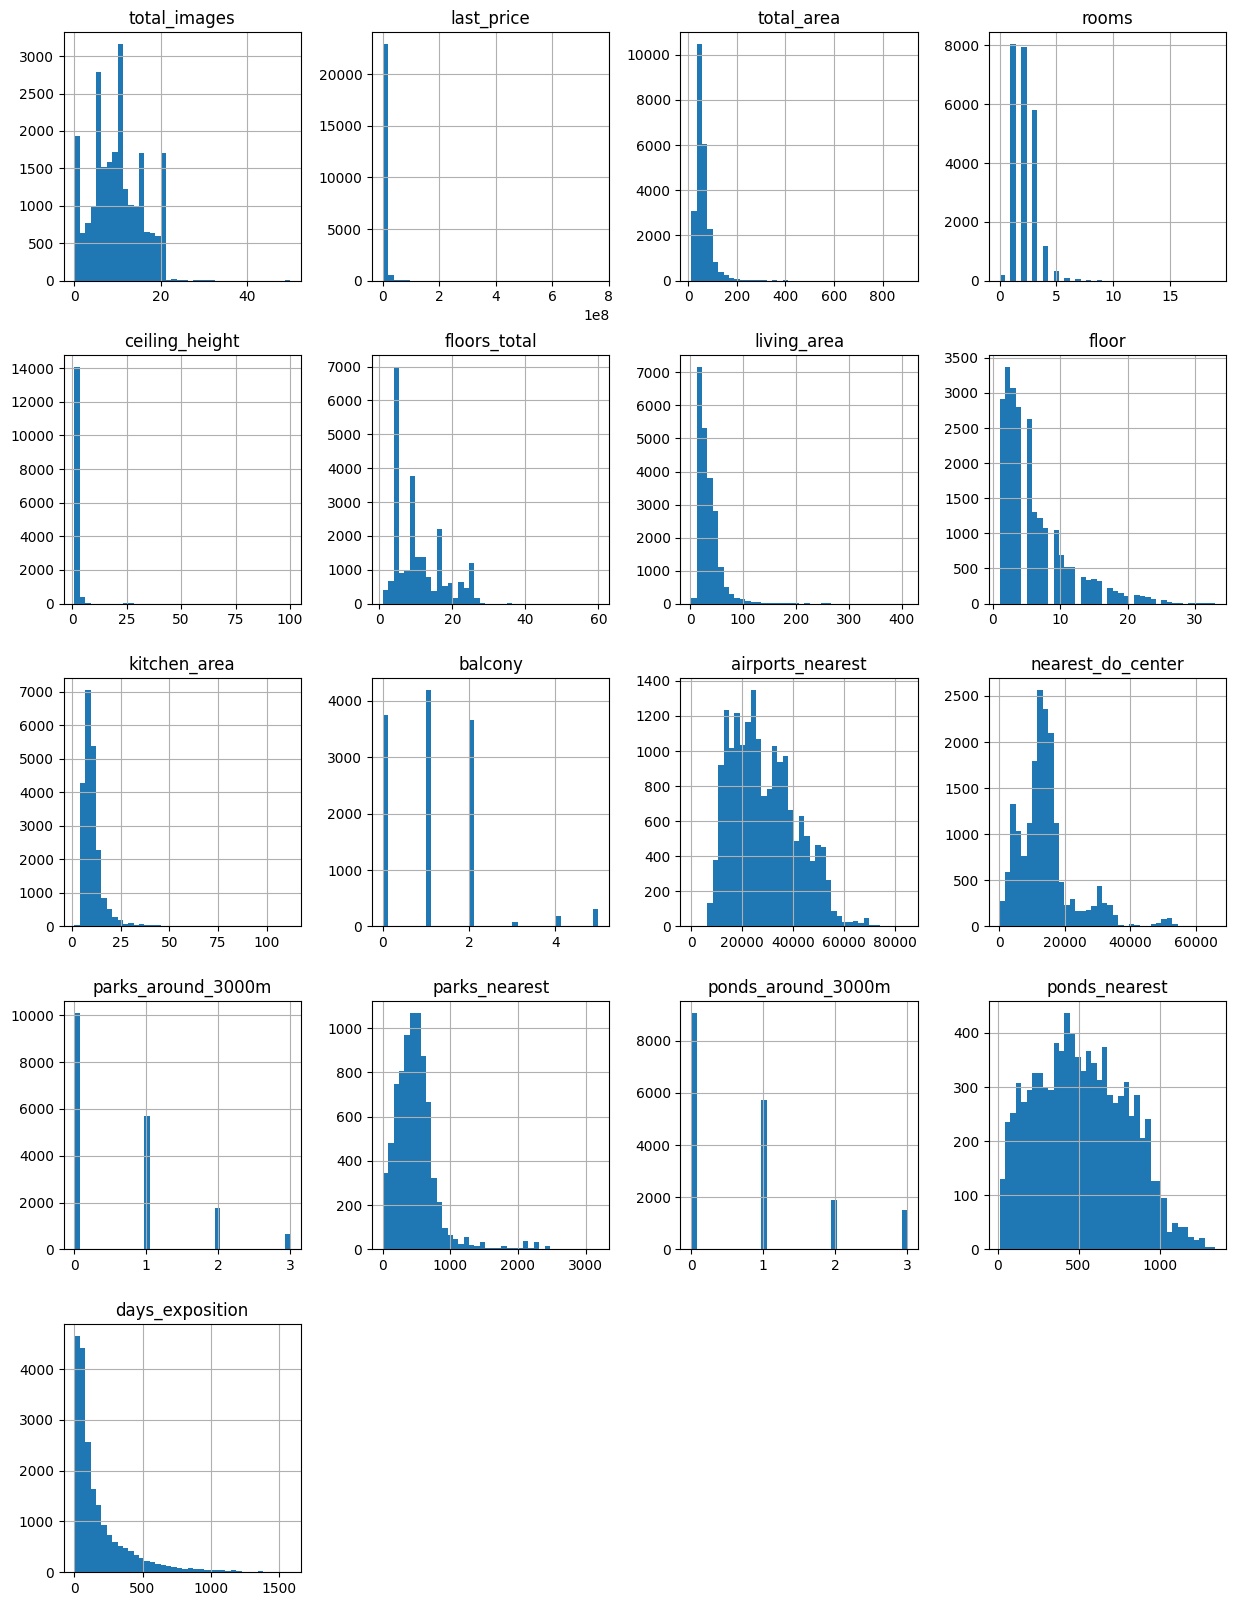

In [5]:
*_, hists = df.hist(figsize=(15, 20), bins=40)

Посчитаем общее количество пропусков.

In [6]:
df.isna().sum().sum()

np.int64(101441)

Видим, что их достаточно много.

**Промежуточный вывод**

На первый взгляд данных достаточно для исследования, но они искажены. 

Например, столбец `days_exposition` (активные дни объявления) имеет слишком большое распределение значений на отметке в 0, а столбец `is_apartment` заполнен всего на 2775 строк (11,7%). Следует более детально рассмотреть столбцы и очистить их.

[_назад к содержанию_](#content)

<a class="anchor" id="preproccesing"></a>
### 4. Предобработка данных
* [2.1. Работа с пропусками](#skip)
* [2.2. Изменение типов данных](#type)
* [2.3. Поиск дубликатов](#duplicated)
* [2.4. Выявление и удаление аномалий](#anomaly)

[_назад к содержанию_](#content)

<a class="anchor" id="skip"></a>
#### 2.1 Работа с пропусками

Проверим, где встречаются пропуски и какова их доля.

In [7]:
df.isna().mean().round(3).sort_values(ascending=False)

is_apartment            0.883
parks_nearest           0.659
ponds_nearest           0.616
balcony                 0.486
ceiling_height          0.388
airports_nearest        0.234
parks_around_3000m      0.233
nearest_do_center       0.233
ponds_around_3000m      0.233
days_exposition         0.134
kitchen_area            0.096
living_area             0.080
floors_total            0.004
locality_name           0.002
rooms                   0.000
first_day_exposition    0.000
total_area              0.000
last_price              0.000
total_images            0.000
studio                  0.000
floor                   0.000
open_plan               0.000
dtype: float64

Двенадцать столбцов имеют пропуски с долей в диапозоне от 8% до 88,3% - их следует обработать.

С этой целью создадим вспомогательную функцию, которая будет отображать кол-во строк, кол-во пропущенных значений и их долю по заданному столбцу - это поможет принять решение о заполнении пропусков.

In [8]:
def missing_info(data, col):
    """
    Считает длину столбца, количество пропусков и их долю.

    Parameters:
    col (str): текстовое наименование столбца.
    data (pd.DataFrame): датафрейм, для которого производится подсчёт.

    Returns:
    None
    """
    info = list()
    skips_len = len(df[col])
    skips_qnt = df[col].isna().sum()
    skips_part = df[col].isna().mean().round(3)
    
    info.append(f"**Всего строк:** {skips_len}")
    info.append(f"**Количество пропусков:** {skips_qnt}")
    info.append(f"**Доля пропусков:** {skips_part}")
    
    display(Markdown('\n\n'.join(info)))

In [9]:
missing_info(df, col='is_apartment')

**Всего строк:** 23699

**Количество пропусков:** 20924

**Доля пропусков:** 0.883

Столбец-рекордсмен `is_apartment` (это аппартаменты):

* возможная причина пропусков: аппартаментами называют жилую зону в коммерческой недвижимости, которая встречается довольное редко; вероятнее всего клиенты не стали указавать эти данные
* решение: заполнить столбец нулями и убедиться, что пропуски устранены

In [10]:
df['is_apartment'].fillna(0, inplace=True)

print(f"Пропусков: {df['is_apartment'].isna().sum()}")

Пропусков: 0


In [11]:
missing_info(df, col='parks_nearest')

**Всего строк:** 23699

**Количество пропусков:** 15620

**Доля пропусков:** 0.659

Столбец `parks_nearest` (расстояние до ближайшего парка):

* возможная причина пропусков: это картографические данные, которые должны передаваться автоматически, вероятно расчёт не мог быть произведен

Требуется проанализировать, какие значения входят в этот столбец - выберем 10 случайных значений.

In [12]:
df['parks_nearest'].sample(10)

1418        NaN
6148        NaN
5325      660.0
5826     1767.0
823         NaN
1111        NaN
4418        NaN
22448     700.0
4435      587.0
4287        NaN
Name: parks_nearest, dtype: float64

Там, где данные есть, они выглядят корректно - расстояние в метрах до ближайшего парка. Возможно не около каждой квартиры есть парки, ведь в другом столбце `parks_around3000` учитываются парки в радиусе 3000 метров.

Проверим эту гипотезу, найдя квартиры, около которых есть парки дальше, чем 3 км.

In [13]:
df.query("parks_nearest > 3000")['parks_nearest']

1590     3064.0
10959    3190.0
19208    3013.0
19430    3190.0
Name: parks_nearest, dtype: float64

Действительно, данные учитываются c удалённостью парков до 3190 метров. Значит пропуски связаны с большим расстоянием парков от остальных квартир. Здесь уместно было бы ввести категориальное значение 'более 3000 метров', однако мы не можем исключить факт технической ошибки, поэтому решено оставить этот столбец без изменений.

In [14]:
missing_info(df, col='ponds_nearest')

**Всего строк:** 23699

**Количество пропусков:** 14589

**Доля пропусков:** 0.616

In [15]:
df['ponds_nearest'].describe()

count    9110.000000
mean      517.980900
std       277.720643
min        13.000000
25%       294.000000
50%       502.000000
75%       729.000000
max      1344.000000
Name: ponds_nearest, dtype: float64

Столбец `ponds_nearest` (расстояние до ближайшего водоёма):

* возможная причина пропусков: это картографические данные, которые должны передаваться автоматически, вероятно расчёт не мог быть произведен
* решение: аналогично столбцу `parks_nearest` оставить без изменений

In [16]:
missing_info(df, col='balcony')

**Всего строк:** 23699

**Количество пропусков:** 11519

**Доля пропусков:** 0.486

Столбец `balcony` (количество балконов):

* возможная причина пропусков: данные вносят сами клиенты, поэтому если поле не заполнено, вероятнее всего в квартире нет балконов (например, на 1 этаже)
* решение: заполнить столбец нулями и убедиться, что пропуски устранены

In [17]:
df['balcony'].fillna(0, inplace=True)

print(f"Пропусков: {df['balcony'].isna().sum()}")

Пропусков: 0


In [18]:
missing_info(df, col='ceiling_height')

**Всего строк:** 23699

**Количество пропусков:** 9195

**Доля пропусков:** 0.388

Высота потолоков точно есть в каждой квартире. Посмотрим на типичные характеристики этого столбца.

In [19]:
df['ceiling_height'].describe()

count    14504.000000
mean         2.771499
std          1.261056
min          1.000000
25%          2.520000
50%          2.650000
75%          2.800000
max        100.000000
Name: ceiling_height, dtype: float64

Можно обнаружить, что медиана почти равна среднему, это говорит о достоверных значениях, при этом 25% данных оказались выше, чем 2.8 метров - это весьма странно. Возможно данные указаны в сантиметрах. Позже обратим на значения в этом столбце больше внимания.

Столбец `ceiling_height` (количество балконов):

* возможная причина пропусков: данные не были внесены
* решение: заполнить пропуски медианным значением

In [20]:
df['ceiling_height'].fillna(df['ceiling_height'].median(), inplace=True)
print(f"Пропусков: {df['ceiling_height'].isna().sum()}")

Пропусков: 0


In [21]:
missing_info(df, col='airports_nearest')

**Всего строк:** 23699

**Количество пропусков:** 5542

**Доля пропусков:** 0.234

In [22]:
df['airports_nearest'].describe()

count    18157.000000
mean     28793.672193
std      12630.880622
min          0.000000
25%      18585.000000
50%      26726.000000
75%      37273.000000
max      84869.000000
Name: airports_nearest, dtype: float64

Столбец `airports_nearest` (расстояние до ближайшего аэропорта):

* возможная причина пропусков: техническая ошибка, т.к. даже квартира в населённом пункте может иметь расстояние до аэропорта в ближайшем крупном городе
* решение: медиана и среднее почти не отличаются, значит данные в столбце имеют примерно схожиме значения; заполним медианным значением

In [23]:
df['airports_nearest'].fillna(df['airports_nearest'].median(), inplace=True)
print(f"Пропусков: {df['ceiling_height'].isna().sum()}")

Пропусков: 0


В следующих двух столбцах одинаковое количество пропусков - 5518. 

In [24]:
missing_info(df, col='ponds_around_3000m')

**Всего строк:** 23699

**Количество пропусков:** 5518

**Доля пропусков:** 0.233

In [25]:
missing_info(df, col='parks_around_3000m')

**Всего строк:** 23699

**Количество пропусков:** 5518

**Доля пропусков:** 0.233

Столбцы `ponds_around_3000m` и `parks_around_3000m` (водоёмы и парки в радиусе 3000 метров):

* возможная причина пропусков: это одни и те же квартиры, рядом с которыми нет парков и водоёмов (например, в посёлках)
* решение: данных много, они являются картографическими и должны подтягиваться автоматически; если эти значения понадобятся при исследовании, нужно их запросить отдельно; решено оставить как есть

In [26]:
missing_info(df, col='nearest_do_center')

**Всего строк:** 23699

**Количество пропусков:** 5519

**Доля пропусков:** 0.233

In [27]:
df['nearest_do_center'].describe()

count    18180.000000
mean     14191.277833
std       8608.386210
min        181.000000
25%       9238.000000
50%      13098.500000
75%      16293.000000
max      65968.000000
Name: nearest_do_center, dtype: float64

Столбец `nearest_do_center`(расстояние до центра):

* возможная причина пропусков: технический сбой
* решение: медиана и среднее почти не отличаются, 
    значит данные в столбце имеют примерно схожиме значения; заполним медианным значением

In [28]:
df['nearest_do_center'].fillna(df['nearest_do_center'].median(), inplace=True)
print(f"Пропусков: {df['nearest_do_center'].isna().sum()}")

Пропусков: 0


In [29]:
missing_info(df, col='days_exposition')

**Всего строк:** 23699

**Количество пропусков:** 3181

**Доля пропусков:** 0.134

In [30]:
df['days_exposition'].describe()

count    20518.000000
mean       180.888634
std        219.727988
min          1.000000
25%         45.000000
50%         95.000000
75%        232.000000
max       1580.000000
Name: days_exposition, dtype: float64

Столбец `days_exposition`(количество дней размещения объявления):

* возможная причина пропусков: объявление ещё может быть активно или выставлено и тут же снято с публикации
* решение: оставить без изменений

In [31]:
missing_info(df, col='kitchen_area')      

**Всего строк:** 23699

**Количество пропусков:** 2278

**Доля пропусков:** 0.096

In [32]:
df['kitchen_area'].describe()

count    21421.000000
mean        10.569807
std          5.905438
min          1.300000
25%          7.000000
50%          9.100000
75%         12.000000
max        112.000000
Name: kitchen_area, dtype: float64

Столбец `kitchen_area`(количество дней размещения объявления):

* возможная причина пропусков: в датафрейме присутствуют квартиры-студии, у которых не может быть площади кухни
* решение: проверить, зависит ли площадь кухни от столбца `studio`, в котором нет пропусков

In [33]:
df.pivot_table(index='studio', values='kitchen_area', aggfunc=lambda x: x.isna().sum())

,kitchen_area
studio,
False,2129
True,149


Только в 149 случаях площадь кухни не указана у квартир-студий. Этот подход не позволяет нам заполнить пропуски. 

Однако столбец важен для анализа, поэтому можно вычислить, сколько процентов занимает площадь кухни по отношению к общей площади и заполнять медианным значением медианных значений, т.к. оно более устойчиво к выбросам.

In [34]:
per_kitchen_median = float((df.pivot_table(index='total_area', values='kitchen_area', aggfunc='median').median() / 100).values)
df['kitchen_area'] = df['kitchen_area'].where(~df['kitchen_area'].isna(), df['total_area'] * per_kitchen_median)

print(f"Пропусков: {df['kitchen_area'].isna().sum()}")

Пропусков: 0


In [35]:
df.iloc[3]

total_images                              0
last_price                       64900000.0
total_area                            159.0
first_day_exposition    2015-07-24T00:00:00
rooms                                     3
ceiling_height                         2.65
floors_total                           14.0
living_area                             NaN
floor                                     9
is_apartment                              0
studio                                False
open_plan                             False
kitchen_area                        18.3645
balcony                                 0.0
locality_name               Санкт-Петербург
airports_nearest                    28098.0
nearest_do_center                    6800.0
parks_around_3000m                      2.0
parks_nearest                          84.0
ponds_around_3000m                      3.0
ponds_nearest                         234.0
days_exposition                       424.0
Name: 3, dtype: object

В 4 строке был пропуск. Сейчас при площади 159 квадратных метров мы получили площадь кухни 18.36.

На первый взгляд значение может показаться маленьким, однако:
* в целом пропусков менее 10%
* мы проводим исследовательский анализ, а не строим точную модель прогнозов
* чем больше общая площадь, тем вероятнее больше комнат, но не площадь кухни
* средняя площадь кухни в РФ по статистике находится в диапозоне 10-15%

Таким образом, пропуски в столбце `kitchen_area` заполнены медианным значением медиан в зависимости от общей площади квартиры.

In [36]:
missing_info(df, col='living_area')

**Всего строк:** 23699

**Количество пропусков:** 1903

**Доля пропусков:** 0.08

In [37]:
df['living_area'].describe()

count    21796.000000
mean        34.457852
std         22.030445
min          2.000000
25%         18.600000
50%         30.000000
75%         42.300000
max        409.700000
Name: living_area, dtype: float64

Столбец `living_area`(жилая площадь):

* возможная причина пропусков: данные не были указаны
* решение: как и в случае со столбцом `kitchen_area`, заполним пропуски медианой медиан по отношению к общей площади квартиры

In [38]:
per_living_median = float((df.pivot_table(index='total_area', values='living_area', aggfunc='median').median() / 100).values)
df['living_area'] = df['living_area'].where(~df['living_area'].isna(), df['total_area'] * per_kitchen_median)

print(f"Пропусков: {df['kitchen_area'].isna().sum()}")

Пропусков: 0


Рассмотрим последние два столбца с пропусками.

In [39]:
missing_info(df, col='floors_total')

**Всего строк:** 23699

**Количество пропусков:** 86

**Доля пропусков:** 0.004

In [40]:
missing_info(df, col='locality_name')

**Всего строк:** 23699

**Количество пропусков:** 49

**Доля пропусков:** 0.002

Столбцы `floors_total` и `locality_name` (всего этажей и название населённого пункта):

* возможная причина пропусков: данные не были указаны
* решение: поскольку доля пропусков очень мала, можно безопасно удалить эти строки из датафрейма

In [41]:
df.dropna(subset=['floors_total'], inplace=True)
df.dropna(subset=['locality_name'], inplace=True)

Посмотрим на распределение пропусков во всём датафрейме после всех операций.

In [42]:
df.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height              0
floors_total                0
living_area                 0
floor                       0
is_apartment                0
studio                      0
open_plan                   0
kitchen_area                0
balcony                     0
locality_name               0
airports_nearest            0
nearest_do_center           0
parks_around_3000m       5500
parks_nearest           15535
ponds_around_3000m       5500
ponds_nearest           14529
days_exposition          3171
dtype: int64

**Промежуточный вывод**

Мы выполнили удаление и заполнение пропусков там, где это возможно:
* is_apartment 
* balcony
* ceiling_height
* airports_nearest 
* nearest_do_center
* kitchen_area
* living_area
* floors_total
* locality_name

Оставили без изменений:

* parks_nearest
* ponds_nearest
* days_exposition          
* parks_around_3000m
* ponds_around_3000m  

[_назад к предобработке_](#preproccesing)

[_назад к содержанию_](#content)

<a class="anchor" id="type"></a>
#### 2.2. Изменение типов данных

Мы уже знакомы с содержанием столбцов. Давайте посмотрим, какие типы сооотвествуют каждому столбцу.

In [43]:
df.dtypes

total_images              int64
last_price              float64
total_area              float64
first_day_exposition     object
rooms                     int64
ceiling_height          float64
floors_total            float64
living_area             float64
floor                     int64
is_apartment             object
studio                     bool
open_plan                  bool
kitchen_area            float64
balcony                 float64
locality_name            object
airports_nearest        float64
nearest_do_center       float64
parks_around_3000m      float64
parks_nearest           float64
ponds_around_3000m      float64
ponds_nearest           float64
days_exposition         float64
dtype: object

Столбец `first_day_exposition` содержит дату размещения объявления (без указания часов, минут и секунд) и потребуется для исследовательской части, поэтому необходимо изменить его тип на `pd.Datetime`.

Столбцец `is_apartment` содержит только булевы значения - изменим тип и этого столбца.

Столбцы `floors_total` и `ponds_around_3000m`, `parks_around_3000m` не могут быть 14,5 этажей или 2,1 парка. Для убодства восприятия изменим их тип на `<int>`, хотя это не обязательно.

Остальные колонки не вызывают опасений.

In [44]:
# 2019-03-07T00:00:00

df['first_day_exposition'] = pd.to_datetime(df['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')
df['is_apartment'] = df['is_apartment'].astype(bool, errors='ignore')

df['floors_total'] = df['floors_total'].astype(int, errors='ignore')
df['ponds_around_3000m'] = df['ponds_around_3000m'].astype(int, errors='ignore')
df['parks_around_3000m'] = df['parks_around_3000m'].astype(int, errors='ignore')

Убедимся, что изменения прошли успешно.

In [45]:
df[['is_apartment', 'first_day_exposition', 'floors_total', 'parks_around_3000m', 'ponds_around_3000m', 'last_price']].dtypes

is_apartment                      bool
first_day_exposition    datetime64[ns]
floors_total                     int64
parks_around_3000m             float64
ponds_around_3000m             float64
last_price                     float64
dtype: object

**Промежуточный вывод**

Мы изменили тип столбца, содержащий дату, чтобы иметь возможность использовать математические операции, а также привели столбец `is_apartment` к типу `<bool>`, т.к. он содержит значения 0 и 1.

Cтолбцы `floors_total`, `parks_around_3000m`, `ponds_around_3000m` - к типу `<int>`.

[_назад к предобработке_](#preproccesing)

[_назад к содержанию_](#content)

<a class="anchor" id="duplicated"></a>
#### 2.3. Поиск дубликатов

Сначала проверим общее количество строк дубликатов по всем колонкам.

In [46]:
df['locality_name'].duplicated().sum()

np.int64(23201)

Явных дубликатов не найдено. Следует посмотреть уникальные значения в единственном текстовом столбце `locality_name`.

In [47]:
df['locality_name'].unique()

array(['Санкт-Петербург', 'посёлок Шушары', 'городской посёлок Янино-1',
       'посёлок Парголово', 'посёлок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок городского типа Красный Бор', 'Гатчина', 'поселок Мурино',
       'деревня Фёдоровское', 'Выборг', 'Кронштадт', 'Кировск',
       'деревня Новое Девяткино', 'посёлок Металлострой',
       'посёлок городского типа Лебяжье',
       'посёлок городского типа Сиверский', 'поселок Молодцово',
       'поселок городского типа Кузьмоловский',
       'садовое товарищество Новая Ропша', 'Павловск',
       'деревня Пикколово', 'Всеволожск', 'Волхов', 'Кингисепп',
       'Приозерск', 'Сестрорецк', 'деревня Куттузи', 'посёлок Аннино',
       'поселок городского типа Ефимовский', 'посёлок Плодовое',
       'деревня Заклинье', 'поселок Торковичи', 'поселок Первомайское',
       'Красное Село', 'посёлок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', '

Есть некоторые проблемы, который могут усложнить анализ:
* поселок, посёлок, посёлок городского типа, годской посёлок, коттеджный посёлок, поселок станции

Приведем наименования посёлков по одному принципу.

In [48]:
wrong_locality_names = ['поселок', 'посёлок городского типа', 'городской посёлок', 'коттеджный посёлок', 'поселок станции', 'посёлок станции']

df['locality_name'] = df['locality_name'].str.strip().str.lower().replace(wrong_locality_names, 'посёлок', regex=True).str.title()

df['locality_name'].value_counts().head(10)

locality_name
Санкт-Петербург      15651
Посёлок Мурино         552
Посёлок Шушары         439
Всеволожск             398
Пушкин                 369
Колпино                338
Посёлок Парголово      327
Гатчина                307
Деревня Кудрово        299
Выборг                 237
Name: count, dtype: int64

**Промежуточный вывод**

Явных дубликатов в датафрейме нет. Мы привели к одному виду наименование посёлков.

[_назад к предобработке_](#preproccesing)

[_назад к содержанию_](#content)

<a class="anchor" id="anomaly"></a>
#### 2.4. Выявление и удаление аномалий

Проверим наличие редких и выбивающихся значений в столбцах, кроме картографических, т.к. проверить их достоверность не представляется возможным. Кроме того, не все из них понадобятся для ответа на поставленные вопросы.

* `is_apartment`
* `studio`
* `studio`

Содержат булевый тип - то есть 1 или 0 (True or False), и мы уже убедились, что аномалий там нет.

Кроме того, столбец `locality_name` содержит наименование локации. 
Проверить существование каждой не представляется возможным.

Для остальных числовых столбцов построим диаграмы размаха и проверим на выбросы.

Стобец `total_images`.

count    23565.000000
mean         9.878421
std          5.681156
min          0.000000
25%          6.000000
50%          9.000000
75%         14.000000
max         50.000000
Name: total_images, dtype: float64

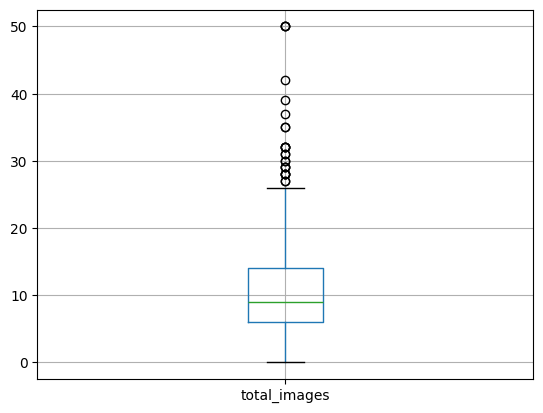

In [49]:
df.boxplot('total_images', showfliers=True)
df['total_images'].describe()

Основное количество фотографий уклыдывается в диапозон от 6 до 14 - это вполне реальные данные, ведь фото помогают продать квартиру быстрее. При этом есть те, кто не добавлял фото, а также 25% данных содержат значения больше, чем 26.

Посчитаем количество фото, чтобы оценить возможность удаления таких больших и нетипчных значений.

In [50]:
df.query("total_images > 26")['total_images'].count()

np.int64(25)

Всего 25 значений из 23565 - данные смело можно удалить, т.к. мы всё-таки продаём квартиры, а не соревнуемся, кто больше сделает фотографий).

In [51]:
df['total_images'] = df.loc[df['total_images'] < 26, 'total_images']

Стобец `last_price`.

count    2.356500e+04
mean     6.540058e+06
std      1.091093e+07
min      1.219000e+04
25%      3.400000e+06
50%      4.646000e+06
75%      6.790000e+06
max      7.630000e+08
Name: last_price, dtype: float64

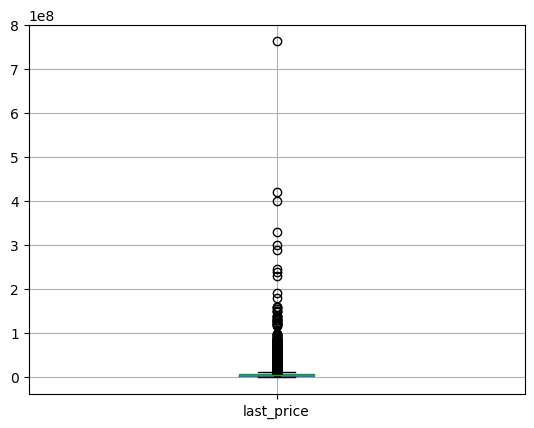

In [52]:
df.boxplot('last_price', showfliers=True)
df['last_price'].describe()

В данных есть аномально низкая стоимость. Сейчас на рынке не может быть даже комнаты дешевле, чем 500000 рублей.

Есть и квартиры дороже 20 миллионов.
Проверим их количество и в каком городе они продавались, т.к. возмонжно в Санкт-Петербурге это нормальная цена.

In [53]:
df[(df['last_price'] > 20000000) | ((df['last_price'] < 500000))]['last_price'].count()

np.int64(718)

In [54]:
df[(df['last_price'] > 20000000) | ((df['last_price'] < 500000))]['locality_name'].value_counts()

locality_name
Санкт-Петербург         687
Пушкин                    9
Сланцы                    4
Деревня Старополье        3
Петергоф                  2
Красное Село              1
Посёлок Будогощь          1
Посёлок Репино            1
Колпино                   1
Деревня Бор               1
Посёлок Свирь             1
Зеленогорск               1
Сестрорецк                1
Деревня Вахнова Кара      1
Деревня Ям-Тесово         1
Деревня Выскатка          1
Всеволожск                1
Посёлок Совхозный         1
Name: count, dtype: int64

Действительно, большинство дорогих квартир находится в гор. Санкт-Петербург.

In [55]:
df.query("locality_name == 'Санкт-Петербург' and last_price > 20000000")['last_price'].count()

np.int64(686)

Из 15651 квартир в Санкт-Петербурге 686 (или 4,3%) стоят более 20 миллионов.

Такие квартиры могут отличаться от большинства квадратурой, планировкой, ремонтом и т.п. - их можно было бы оставить в случае, если бы нас интересовали такие квартиры. Однако для текущей выборки такие значения являются выбросами, поэтому мы удалим их. А также те квартиры, которые стоят менее 500000, т.к. цена неправдоподобная.

In [56]:
df = df[(df['last_price'] > 500000) & (df['last_price'] < 20000000)]

Столбец `total_area`.

count    22827.000000
mean        56.656972
std         24.585044
min         12.000000
25%         40.000000
50%         51.000000
75%         67.000000
max        320.000000
Name: total_area, dtype: float64

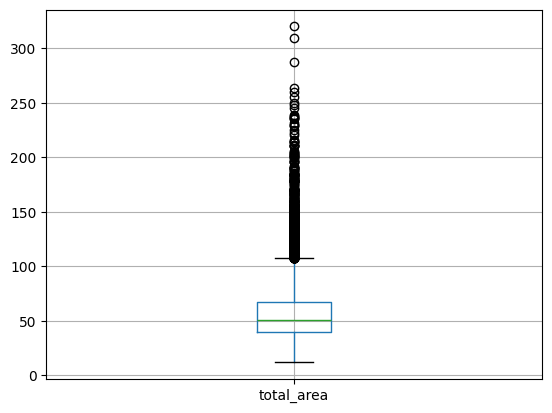

In [57]:
df.boxplot('total_area', showfliers=True)
df['total_area'].describe()

Большинство значений находятся в диапозоне от 40 до 69,7 квадратных метров, но есть и аномально низкие и аномально большие значения. Проверим, сколько квартир имеют площадь менее 10 и более 120 кв. м.

In [58]:
df[(df['total_area'] > 120) | ((df['total_area'] < 15))]['total_area'].count()

np.int64(518)

Удалим выбивающиеся значения.

In [59]:
df = df[(df['total_area'] >= 15) & (df['total_area'] <= 120)]

Столбец `rooms`.

array([3, 1, 2, 4, 0, 5, 6, 7])

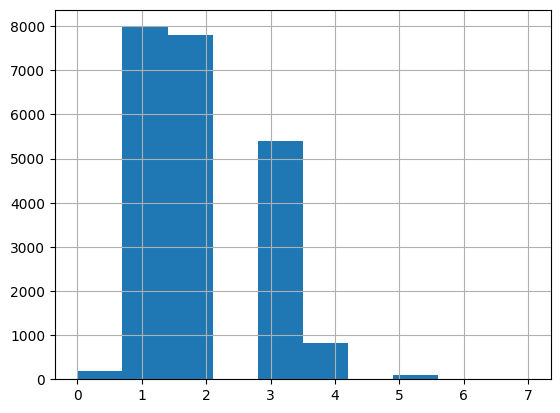

In [60]:
df['rooms'].hist()
df['rooms'].unique()

Возможно большое количество комнат связано с большой общей площадью.

In [61]:
df[(df['rooms'] > 5) & (df['total_area'] > 100)]['rooms'].count()

np.int64(8)

Да, такие квартиры есть, но их всего 8.

Посмотрим на минимальное значение - 0.

In [62]:
df[(df['rooms'] == 0) & ((df['open_plan'] == True))]['rooms'].count()

np.int64(58)

Объявления, где указано 0 комнат, связаны с тем, что квартиры имеют свободную планировку, однако это как минимум 1 комната, поэтому заменим такие значения на 1.

In [63]:
df.loc[df['rooms'] == 0, 'rooms'] = 1

<Axes: >

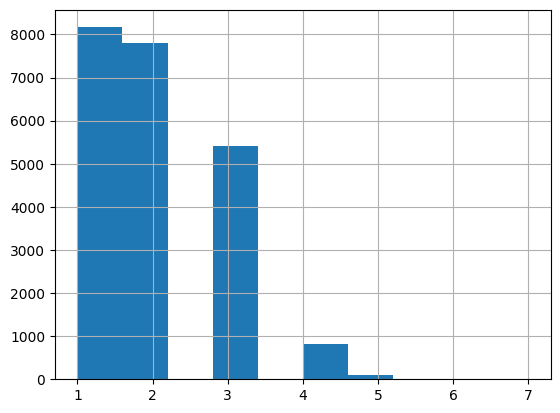

In [64]:
df['rooms'].hist()

Теперь распределение кажется более реалистичным - множество квартир с 1-2 комнатами, чуть меньше с 3 и совсем немного с 4-5.

Столбец `ceiling_height`.

count    22309.000000
mean         2.709017
std          1.011647
min          1.000000
25%          2.600000
50%          2.650000
75%          2.700000
max        100.000000
Name: ceiling_height, dtype: float64

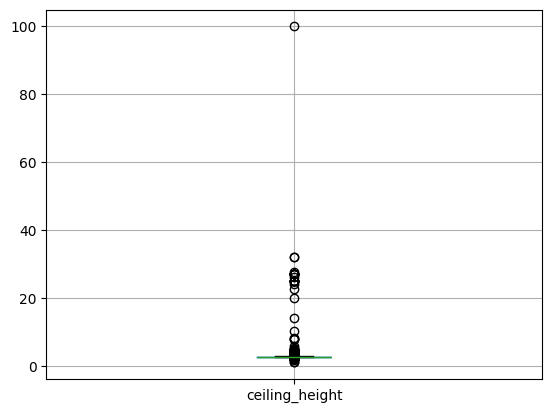

In [65]:
df.boxplot('ceiling_height', showfliers=True)
df['ceiling_height'].describe()

Мы уже предполагали, что в этом столбце высота потолков от 2.7 метров указана в метрах.

При этом высота 100 (max) / 10 = 10 метров слишком нереалистичное значение. Тем более средняя высота потолков по данным интернета 2,65 метров.

Переведём все в метры и посчитаем, какого кол-ва данных мы лишимся.

In [66]:
df['ceiling_height'] = df['ceiling_height'].where(df['ceiling_height'] <= 40, df['ceiling_height'] / 10)

print(f"Доля значений выше 3: {df[df['ceiling_height'] > 3]['ceiling_height'].size / df['ceiling_height'].size}")

Доля значений выше 3: 0.048007530593034205


Удалим эти значения, отличные от 3 метров.

<Axes: >

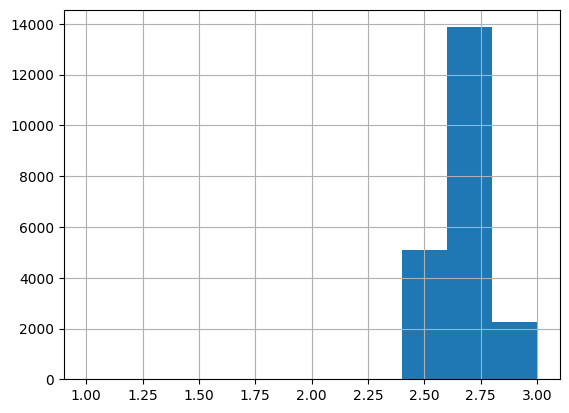

In [67]:
df = df[df['ceiling_height'] <= 3]
df['ceiling_height'].hist()

Столбец `floors_total`.

count    21238.000000
mean        11.044166
std          6.669314
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64

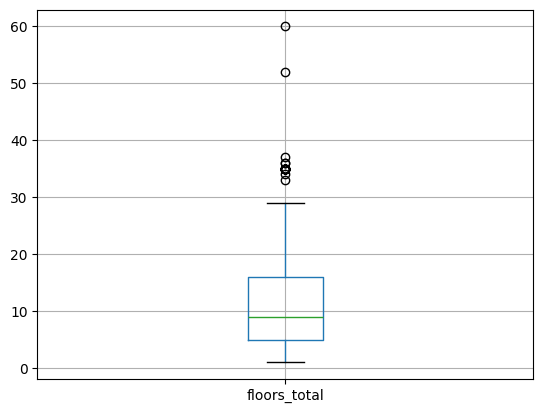

In [68]:
df.boxplot('floors_total', showfliers=True)
df['floors_total'].describe()

In [69]:
df['floors_total'].unique()

array([16, 11,  5, 12, 26, 24, 27,  9,  6, 14, 17, 25,  3, 23, 19, 18,  4,
       22, 10,  7, 13, 15,  2,  8, 20, 28, 36, 21, 35, 34, 60,  1, 29, 33,
       52, 37])

In [70]:
df[df['floors_total'] > 25]['floors_total'].count()

np.int64(339)

Самое высокое здание в Санкт-Петербурге - 25 этажей. По какой-то причине у нас есть 34, 35 и даже 60 этажей (больше похоже на номера квартир).
Заменим такие значения на 25 - это всё ещё высоко, но более правдоподобно.

Самое низкое - 1 и 2 этажи. Мы рассматриваем квартиры, а не дома. Скорее всего здесь указали свой этаж. Заменим 1, 2 этажи на 3.

array([16, 11,  5, 12, 25, 24,  9,  6, 14, 17,  3, 23, 19, 18,  4, 22, 10,
        7, 13, 15,  8, 20, 21])

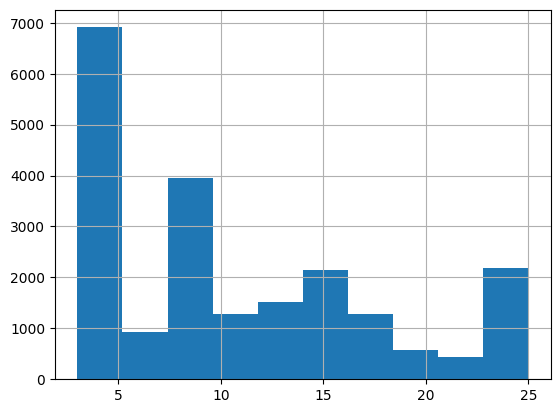

In [71]:
df['floors_total'] = df['floors_total'].where(df['floors_total'] <= 25, 25)
df['floors_total'] = df['floors_total'].where(df['floors_total'] >= 3, 3)
df['floors_total'].hist()
df['floors_total'].unique()

Теперь распределение кажется более правдоподобным - больше всего домов с 5 этажами. Чуть меньше с 10, затем с 15 и 25.

Столбцы `living_area` и `kitchen_area`.

In [72]:
df.pivot_table(index='total_area', values=['living_area', 'kitchen_area'])

,kitchen_area,living_area
total_area,,
15.0,1.732500,1.732500
15.5,1.790250,10.000000
16.0,1.848000,13.000000
17.0,2.481750,12.500000
17.2,1.986600,1.986600
...,...,...
119.3,18.700000,80.000000
119.5,23.500000,67.100000
119.6,64.000000,36.400000


Странно, что кухня в первой строке входит в жилую площадь. Обычно в ней находятся только спальни, гостинные, а всё остальное обозначают как не жилую. Изучим этот момент более подробно при исследовании данных, а пока попробуем удалить выбывающиеся значения, т.к. кухня 1,73 кв. м. или жилая площадь 1,73 кв.м. кажутся слишком малыми значениями при общей площади 15 квадратов (студия минимальной застройки).

count    21238.000000
mean         9.371480
std          4.215786
min          1.300000
25%          6.500000
50%          8.600000
75%         11.000000
max         64.000000
Name: kitchen_area, dtype: float64

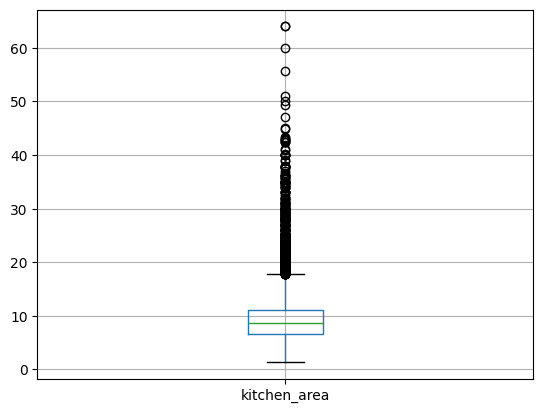

In [73]:
df.boxplot('kitchen_area', showfliers=True)
df['kitchen_area'].describe()

In [74]:
df.loc[df['kitchen_area'] > 20, ['total_area', 'kitchen_area']].mean()

total_area      81.861517
kitchen_area    26.709145
dtype: float64

Квартиры, в которых площадь кухни больше 20, выглядят реалистичными, т.к. относятся к квартирам, где общая площадь тоже большая.

In [75]:
print(df.loc[df['kitchen_area'] < 3, ['total_area', 'kitchen_area']].mean())
print(df.loc[df['kitchen_area'] < 3, ['total_area', 'kitchen_area']].count())

total_area      23.468724
kitchen_area     2.640439
dtype: float64
total_area      196
kitchen_area    196
dtype: int64


Есть 196 квартир, в которых общая площадь и площадь кухни невелики. Выглядит правдоподобно.

Решение по столбцу `kitchen_area` - оставить без изменений.

count    21238.000000
mean        28.581629
std         14.241506
min          1.732500
25%         17.500000
50%         28.000000
75%         38.000000
max        100.000000
Name: living_area, dtype: float64

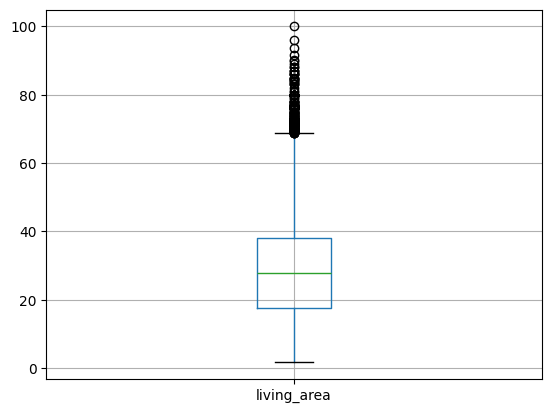

In [76]:
df.boxplot('living_area', showfliers=True)
df['living_area'].describe()

In [77]:
print(df.loc[df['living_area'] > 65, ['total_area', 'living_area']].mean())
print(df.loc[df['living_area'] > 65, ['total_area', 'living_area']].count())
print(df.loc[df['living_area'] < 5, ['total_area', 'living_area', 'studio']])

total_area     106.201049
living_area     72.549580
dtype: float64
total_area     286
living_area    286
dtype: int64
       total_area  living_area  studio
30           32.8      3.78840   False
44           40.0      4.62000   False
60           35.0      4.04250   False
133          31.0      3.58050   False
164          40.3      4.65465   False
...           ...          ...     ...
23530        30.0      3.46500   False
23534        39.0      4.50450   False
23554        26.0      3.00300    True
23632        38.0      4.38900   False
23679        35.0      4.04250   False

[572 rows x 3 columns]


268 квартир имеют адекватную жилую площадь, оставим без изменений.
А квартиры c жилой площадью менее 5 квадратов не являются студиями. Решено также их удалить, несмотря на количество в 573 строки.

In [78]:
df = df[(df['living_area'] < 65) & (df['living_area'] >= 5)]

Столбец `balcony`.

count    20365.000000
mean         0.628333
std          0.966637
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          5.000000
Name: balcony, dtype: float64

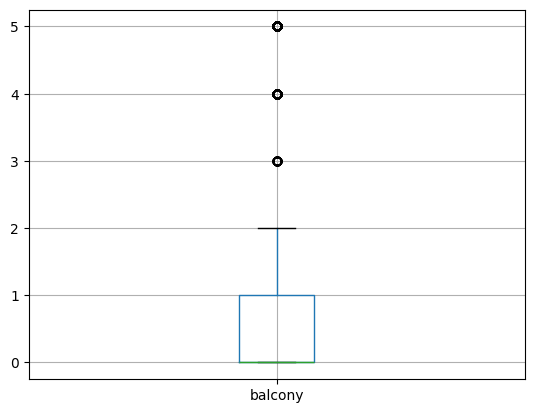

In [79]:
df.boxplot('balcony', showfliers=True)
df['balcony'].describe()

In [80]:
df.query("balcony > 2")[['total_area', 'balcony']]

,total_area,balcony
41,74.00,5.0
116,97.20,5.0
250,51.70,4.0
267,120.00,5.0
311,86.00,5.0
...,...,...
23474,40.50,4.0
23496,55.30,3.0
23497,55.40,4.0
23506,65.00,3.0


3, 4, 5 балконов - большая редкость. Однако по диаграме размаха промежуточных значений нет. 

Поскольку нет логичной причины предположить, почему так много балконов у некоторых небольших квартир, оставим этот столбец без изменений.

Столбец `airports_nearest`.

count    20365.000000
mean     28553.838203
std      11372.342495
min          0.000000
25%      20735.000000
50%      26726.000000
75%      35232.000000
max      84869.000000
Name: airports_nearest, dtype: float64

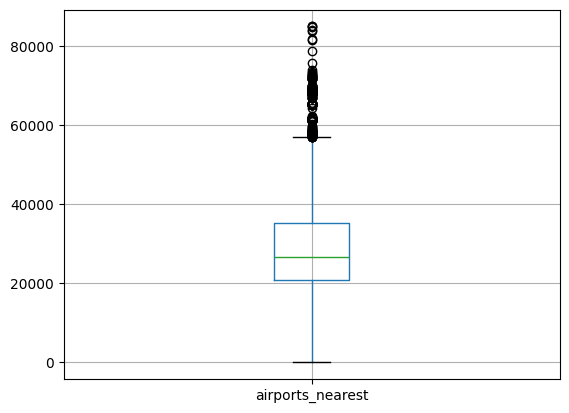

In [81]:
df.boxplot('airports_nearest', showfliers=True)
df['airports_nearest'].describe()

In [82]:
df.loc[(df['airports_nearest'] > 57000) | (df['airports_nearest'] < 1000), 'airports_nearest'].count()

np.int64(215)

200 квартир, от которых аэропот на рассотонии 57 км. Скорее всего, это посёлки.

Расстояние в 0 метров говорит нам о том, что квартиры находятся рядом с аэропортом, что является подозрительным - рядом с аэропортами могут быть только гостиницы. Решено оставить эти значения.

Столбец `nearest_do_center`.

count    20365.000000
mean     14685.357010
std       7278.062268
min        399.000000
25%      11934.000000
50%      13098.500000
75%      15589.000000
max      65968.000000
Name: nearest_do_center, dtype: float64

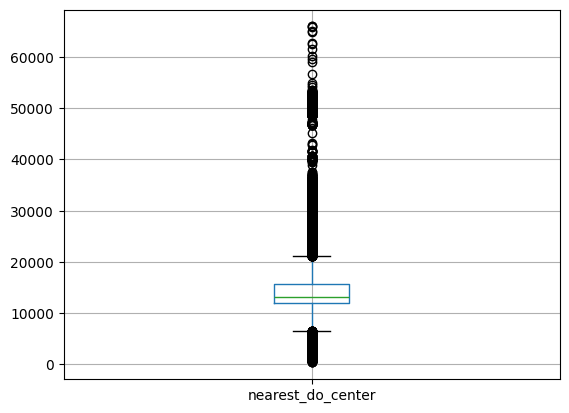

In [83]:
df.boxplot('nearest_do_center', showfliers=True)
df['nearest_do_center'].describe()

Создаётся впечатление, что расстояние считается до центра Санкт-Петербурга, значит:

* расстояние менее 5000 будет в локации Санкт-Петербург
* расстояние более 20000 в других локациях

Проверим это.

In [84]:
df.loc[(df['nearest_do_center'] > 20000), ['locality_name', 'nearest_do_center']]

,locality_name,nearest_do_center
11,Ломоносов,51677.0
13,Петергоф,33058.0
14,Пушкин,30759.0
28,Пушкин,30710.0
33,Колпино,32321.0
...,...,...
23660,Красное Село,41718.0
23669,Колпино,30473.0
23678,Пушкин,27977.0
23685,Ломоносов,51818.0


In [85]:
df.loc[(df['nearest_do_center'] < 5000), ['locality_name', 'nearest_do_center']]

,locality_name,nearest_do_center
24,Санкт-Петербург,2336.0
61,Санкт-Петербург,4288.0
137,Санкт-Петербург,4263.0
138,Санкт-Петербург,2913.0
159,Санкт-Петербург,4937.0
...,...,...
23602,Санкт-Петербург,2345.0
23609,Санкт-Петербург,4087.0
23644,Санкт-Петербург,4415.0
23665,Санкт-Петербург,4946.0


Расстояние, действительно, считается до центра Санкт-Петербурга. Удалять такие выбросы нет причин, т.к. это может потребоваться при исследовании.

Столбцы `parks_around_3000m` и `ponds_around_3000m`.

count    15231.000000
mean         0.536012
std          0.742571
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          3.000000
Name: parks_around_3000m, dtype: float64

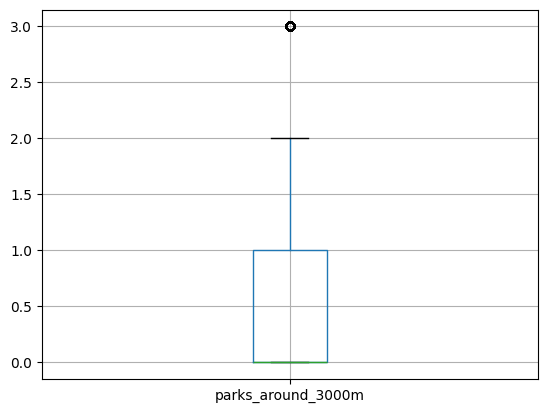

In [86]:
df.boxplot('parks_around_3000m', showfliers=True)
df['parks_around_3000m'].describe()

count    15231.000000
mean         0.693717
std          0.884246
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          3.000000
Name: ponds_around_3000m, dtype: float64

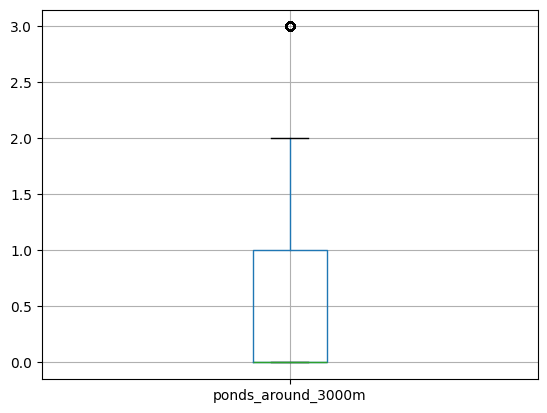

In [87]:
df.boxplot('ponds_around_3000m', showfliers=True)
df['ponds_around_3000m'].describe()

Парков и водоёмов от 1 до 3 - оставим столбцы без изменений. 

Столбец `days_exposition`.

Мы пропустили обработку пропусков в этом столбце.

In [88]:
df['days_exposition'].isna().sum()

np.int64(2519)

count    17846.000000
mean       172.568475
std        210.235219
min          1.000000
25%         43.000000
50%         92.000000
75%        218.000000
max       1580.000000
Name: days_exposition, dtype: float64

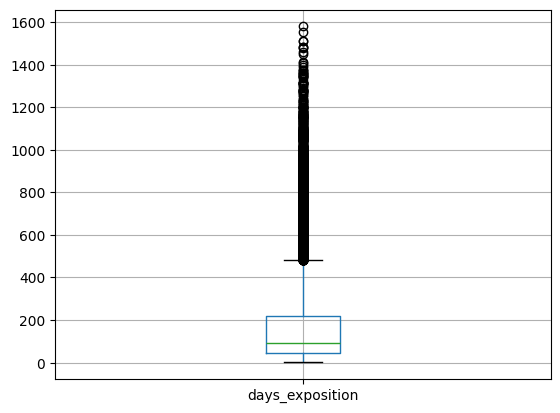

In [89]:
df.boxplot('days_exposition', showfliers=True)
df['days_exposition'].describe()

По всей видимости, после прошествии 500 дней многие забывают снять объявление с публикации - квартира была продана или нет?

Ещё причины долгого размещения: она стоит дорого, находится в неудачной локации.

Оценим количество таких квартир.

In [90]:
df.loc[df['days_exposition'] > 500, 'days_exposition'].count()

np.int64(1368)

Довольно много - 1275, однако мы должны будет ответить на вопрос, как быстро квартиры продаются. Решено оставить, как есть.

**Промежуточный вывод**

Мы устранили пропуски и обработали аномальные значения там, где это возможно. Также привели наименование локаций в единый стиль и проверили наличие явных и неявных дубликатов.

Итого осталось 20365 строк (86%) из первоначальных 23699, однако данные стали более чистыми для дальнейшего анализа.

[_назад к предобработке_](#preproccesing)

[_назад к содержанию_](#content)

<a class="anchor" id="attribute"></a>
### 5. Добавление новых признаков

Чтобы ответить на поставленные вопросы, требуется ввести несколько новых признаков на основе текущих.

Добавим цену за квадратный метр.

In [91]:
df['price_sqr_m'] = round((df['last_price'] / df['total_area']), 0)
df.head(3)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,nearest_do_center,parks_around_3000m,parks_nearest,ponds_around_3000m,ponds_nearest,days_exposition,price_sqr_m
0,20.0,13000000.0,108.0,2019-03-07,3,2.70,16,51.0,8,False,...,0.0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN,120370.0
1,7.0,3350000.0,40.4,2018-12-04,1,2.65,11,18.6,1,False,...,2.0,Посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0,82921.0
2,10.0,5196000.0,56.0,2015-08-20,2,2.65,5,34.3,4,False,...,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0,92786.0


Обновим индексы датафрейма.

In [92]:
df.reset_index(drop=True, inplace=True)

Добавим день недели, месяц и год публикации, чтобы иметь возможность рассчитать по признаку `first_day_exposition` скорость продаж квартир.

In [93]:
df['weekday_publicated'], df['month_publicated'], df['year_publicated'] = \
df['first_day_exposition'].dt.weekday, df['first_day_exposition'].dt.month, df['first_day_exposition'].dt.year
df.columns

Index(['total_images', 'last_price', 'total_area', 'first_day_exposition',
       'rooms', 'ceiling_height', 'floors_total', 'living_area', 'floor',
       'is_apartment', 'studio', 'open_plan', 'kitchen_area', 'balcony',
       'locality_name', 'airports_nearest', 'nearest_do_center',
       'parks_around_3000m', 'parks_nearest', 'ponds_around_3000m',
       'ponds_nearest', 'days_exposition', 'price_sqr_m', 'weekday_publicated',
       'month_publicated', 'year_publicated'],
      dtype='object')

Тип этажа квартиры. Значения:
* первый
* последний 
* другой

In [94]:
def floor_group(row):
    """
    Определяет группу этажности по входной строке датафрейма.

    Parameters:
    row: строка, содержащая значения текущего этажа и всего этажей

    Returns:
    str: группа этажности: первый, последний или другой
    """
    curr_floor = row['floor']
    floors_total = row['floors_total']
    
    if curr_floor == 1:
        return 'первый'
    elif curr_floor == floors_total:
        return 'последний'
    else:
        return 'другой'
    
df['floor_group'] = df.apply(floor_group, axis = 1)
df[['floors_total', 'floor', 'floor_group']].head(10)

,floors_total,floor,floor_group
0,16,8,другой
1,11,1,первый
2,5,4,другой
3,12,5,другой
4,25,6,другой
5,24,22,другой
6,25,26,другой
7,9,7,другой
8,12,3,другой
9,5,4,другой


Переведём расстояние до центра города из метров до киллометров с математическим округлением.

In [95]:
km = 1000
df['distance_do_center_km'] = round(df['nearest_do_center'] / km, 0)
df[['nearest_do_center', 'distance_do_center_km']]

,nearest_do_center,distance_do_center_km
0,16028.0,16.0
1,18603.0,19.0
2,13933.0,14.0
3,13098.5,13.0
4,19143.0,19.0
...,...,...
20360,34104.0,34.0
20361,13098.5,13.0
20362,13098.5,13.0
20363,10364.0,10.0


**Промежуточный вывод**

Добавили новые признаки:

* цена одного квадратного метра
* день, месяц и год публикации объявления
* тип этажа (первый, последний или другой)
* расстояние до центра в киллометрах

[_назад к содержанию_](#content)

<a class="anchor" id="research"></a>
### 6. Ход исследования
* [5.1 Основные признаки](#parametr)
* [5.2 Как быстро продавались квартиры](#how_fast)
* [5.3 Какие факторы больше всего влияют на полную стоимость](#what_factor)
* [5.4 ТОП-10 населённых пунктов c самой высокой и низской стоимостью квадратного метра](#top_10)
* [5.5 Как стоимость квадратного метра зависит от удалённости от центра Питера](#how_nearest)

<a class="anchor" id="parametr"></a>
#### 5.1 Основыне признаки

Изучим основные признаки популярных квартир для продажи, однако перед этим добавим новый столбец `last_price_mln` для удобства отображения стоимости квартир.

In [96]:
df['last_price_mln'] = df['last_price'] / 1000000
df['last_price_mln'].describe()

count    20365.000000
mean         5.014832
std          2.676919
min          0.520000
25%          3.330000
50%          4.400000
75%          5.999999
max         19.999000
Name: last_price_mln, dtype: float64

In [97]:
def show_my_histogram(column):
    plt.figure(figsize=(9, 4))

    df[column].hist(bins=20, grid=True, legend=True, edgecolor='black')
    plt.ylabel('quantity')
    plt.show()

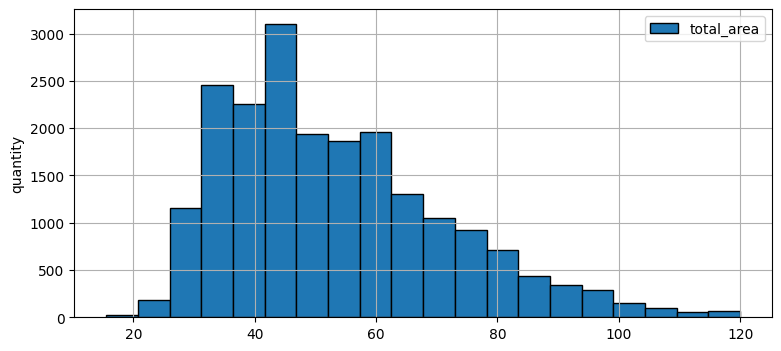

In [98]:
show_my_histogram('total_area')

Наблюдения по столбцу `total_area`:

* основная доля квартир имеют общую площадь от 30 до 70 квадратных метров - это однокомнатные и двухкомнатые квартиры
* чем больше общей площади, тем меньше квартир
* больше всего квартир с общей площадью 40 квадратных метров
* меньше всего кватир с общей площадью 110 квадратов и более

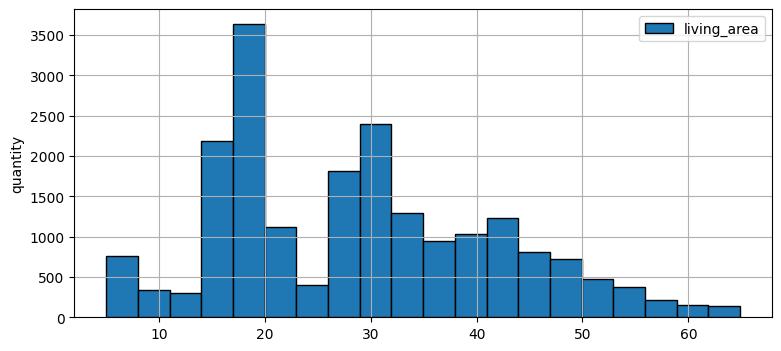

In [99]:
show_my_histogram('living_area')

Наблюдения по столбцу `living_area`:
* ожидаемо жилой площади меньше, чем общей, при этом расределение значений хаотичное
* пик около 15-22 квадратных метров и 30-35
* меньше всего квартир с жилой площадью 50 и более квадратных метров

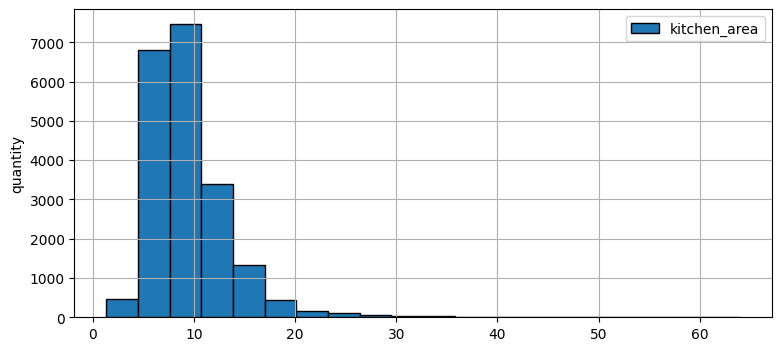

In [100]:
show_my_histogram('kitchen_area')

Наблюдения по столбцу `kitchen_area`:
* основное распределение площадей кухонь находится между 5 и 12 квадратными метрами
* больше всего кухонь от 6 до 10 квадратов
* меньше всего кухонь 17,5 и больше квадратов, а также менее 5

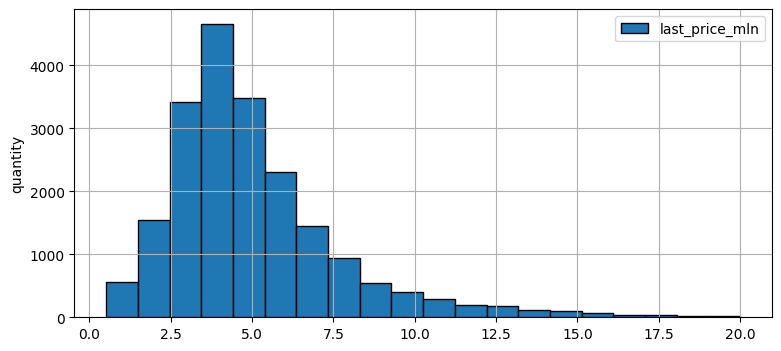

In [101]:
show_my_histogram('last_price_mln')

Наблюдения по столбцу `last_price`:
* основное распределение цен от 2.5 до 7,5 млн рублей
* меньше всего дорогих квартир за 20 миллионов
* больше всего квартир за 4 миллиона

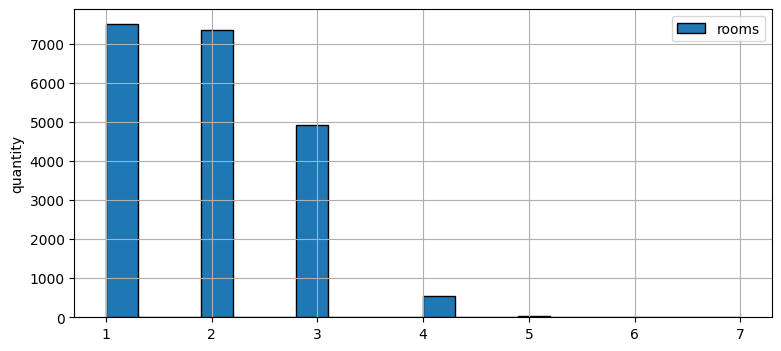

In [102]:
show_my_histogram('rooms')

Наблюдения по столбцу `rooms`:
* основное распределение комнат в квартирах 1-3
* чем меньше комнат, тем больше объявлений
* больше всего квартир с 1 комнотой
* меньше всего квартир с 4 и 5 комнатами

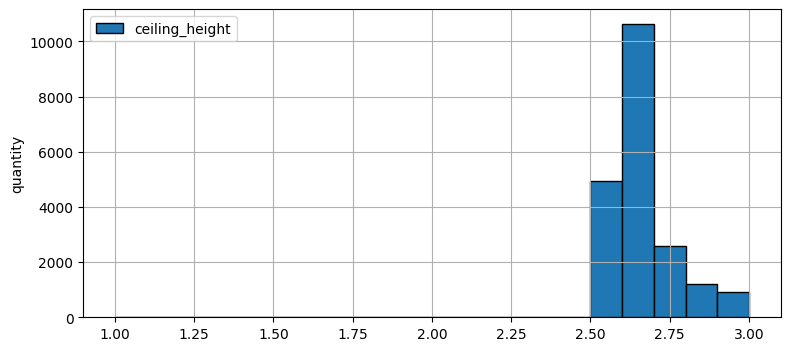

In [103]:
show_my_histogram('ceiling_height')

Наблюдения по столбцу `ceiling_height`:
* основное распределение высоты пололков между 2,5 и 2,75 метров
* больше всего квартир с потолками 2,65 метров (это стандартная высота потолков, похоже на правду)
* меньше всего квартир с потолками 2,25 и 3 метра

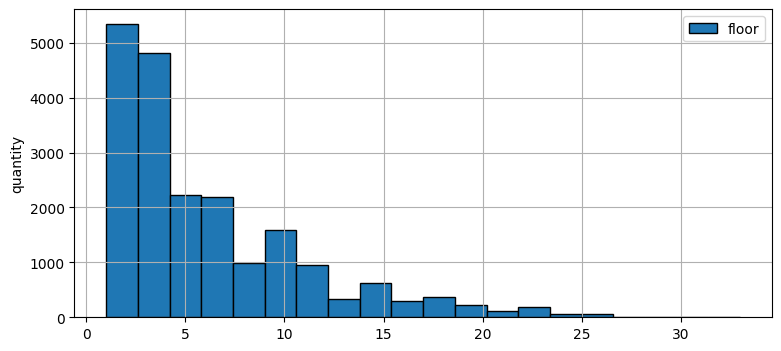

In [104]:
show_my_histogram('floor')

Наблюдения по столбцу `floor`:
* основное распределение этажей от 3 до 10
* больше всего квартир на 3 этаже (в Санкт-Петербурге много трёхэтажных и 5 этажных домов, а также в посёлках)
* меньше всего квартир 25 этажами

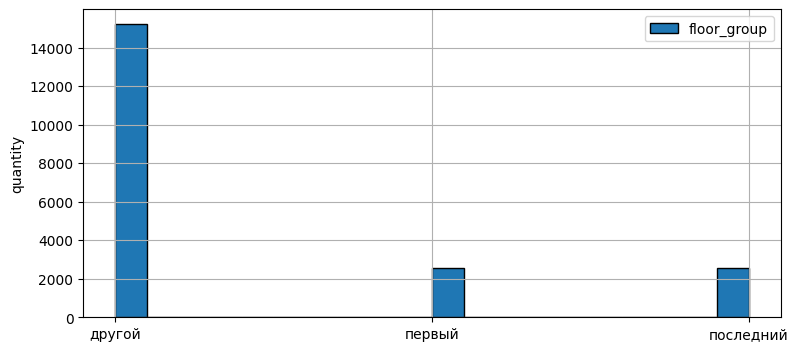

In [105]:
show_my_histogram('floor_group')

Наблюдения по столбцу `floor_group`:
* больше всего продаётся квартир на средних этажах
* одинаковое кол-во квартир на первом и последнем этажах

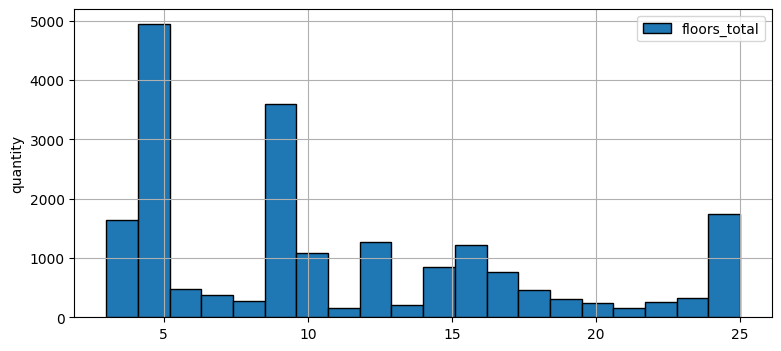

In [106]:
show_my_histogram('floors_total')

Наблюдения по столбцу `floors_total`:
* больше всего продаётся квартир в 5 этажных домах
* также много квартир в 9 этажных и 25 этажных домах
* меньше всего квартир в домакх с нестандартной этажностью (3, 5, 9, 15, 19, 25)

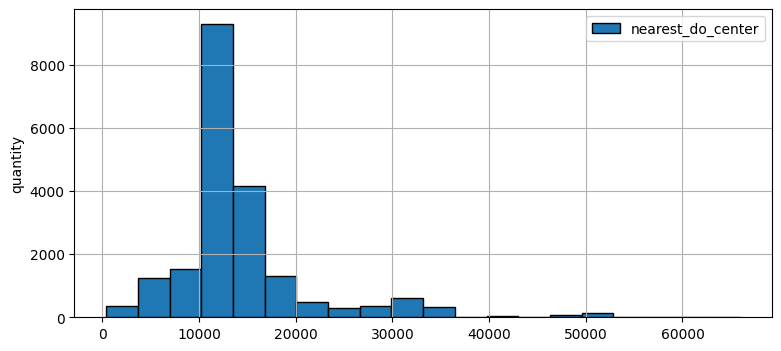

In [107]:
show_my_histogram('nearest_do_center')

Наблюдения по столбцу `nearest_do_center` (в метрах):
* основное распределение между 10000 и 18000 метров - можно предположить, что это окраины Санкт-Петербурга и прилежащие к ним посёлки
* больше всего квартир с расстояним до центра 15000
* меньше всего квартир в центре и очень далеко (более 50000)

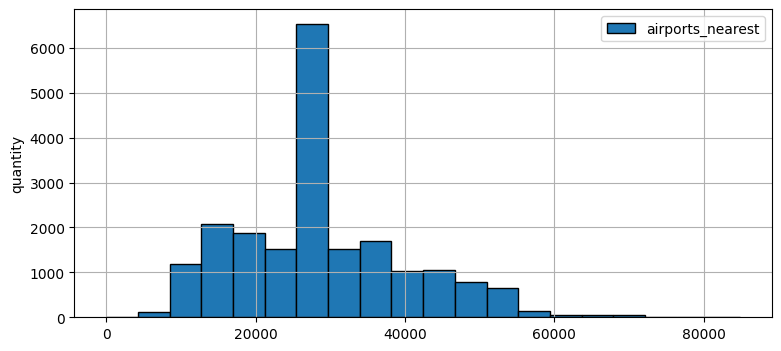

In [108]:
show_my_histogram('airports_nearest')

Наблюдения по столбцу `airports_nearest` (в метрах):
* пик на 28000 метров (возможно, один и тот же район, где часто продают квартиры?)
* остальное распределение от 10000 до 50000 метров в районе 750-1000 объявлений
* меньше всего квартир рядом с аэропотом (не забудьте купить бируши!)

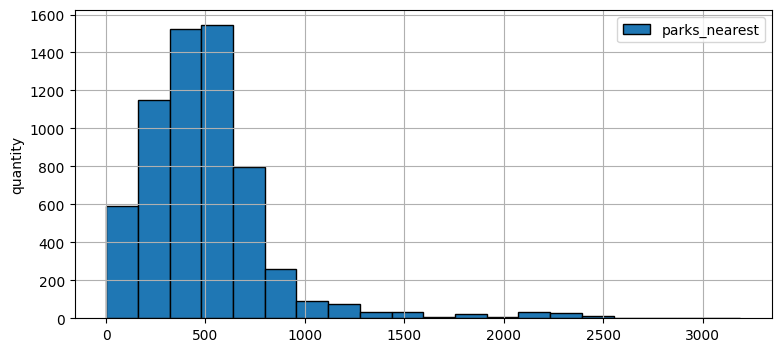

In [109]:
show_my_histogram('parks_nearest')

Наблюдения по столбцу `parks_nearest` (в метрах):
* преимущественная удалённость парков - 250-750 метров (вероятно, это снова Питер)
* есть квартиры, которые находятся в непосредственной близости к паркам
* самое большое расстояние до парка 3000 метров

<Figure size 900x400 with 0 Axes>

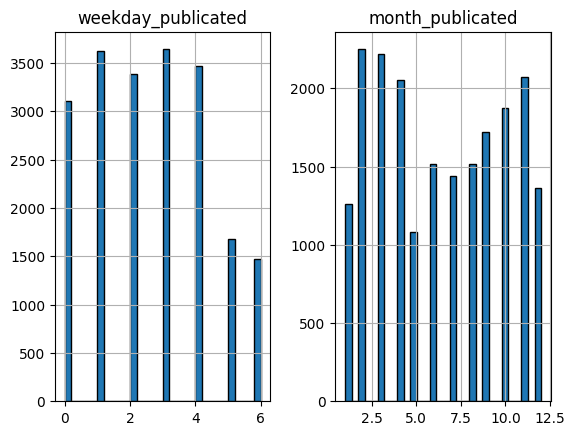

In [110]:
plt.figure(figsize=(9, 4))
df[['weekday_publicated','month_publicated']].hist(bins=30, grid=True, legend=False, edgecolor='black')
plt.show()

Наблюдения по столбцам `week_publicated` и `month_publicated`:
* чаще публикуют объявления во вторник и четверг
* реже публикуют объявления в выходные - субботу и восресенье
* с 2014 наблюдался рост числа объявлений, затем в 2019 произошёл резкий спад
* больше всего объявлений пубоиковали в 2017 и 2018 году

**Промежуточный вывод**

Мы проанализировали основное распределение по важным для продаж квартир характеристикам.

Больше всего продаётся квартир, которые:
* имеют общую площадь от 30 до 70 квадратов с пиком в 40, жилую 19 квадратов и площадь кухни 6 квадратов
* стоят от 2.5 до 7,5 млн
* в пятиэтажках на 2-4 этажах с 1-2 комнатами
* с высотой потолков 2,65
* с расстоянием до центра Санкт-Петербурга 15 км и 28 км до ближайшего аэропорта, а также до парка 400-500 метров

Меньше всего продаётся больших и дорогих квартир.

Таким образом, это стандартный портрет квартиры, однако он не учитывает имеющуюся локацию. Можно сказать, что это средние показатели для Ленинградской области.

Больше всего объявлений было опубликовано в 2017-2018 годах в будние дни.

[_назад к ходу исследования_](#research)

[_назад к содержанию_](#content)

<a class="anchor" id="how_fast"></a>
#### 5.2 Как быстро продавались квартиры

Проверим, как быстро продавались квартиры по признаку `days_exposition` (количество активных дней объявлений).

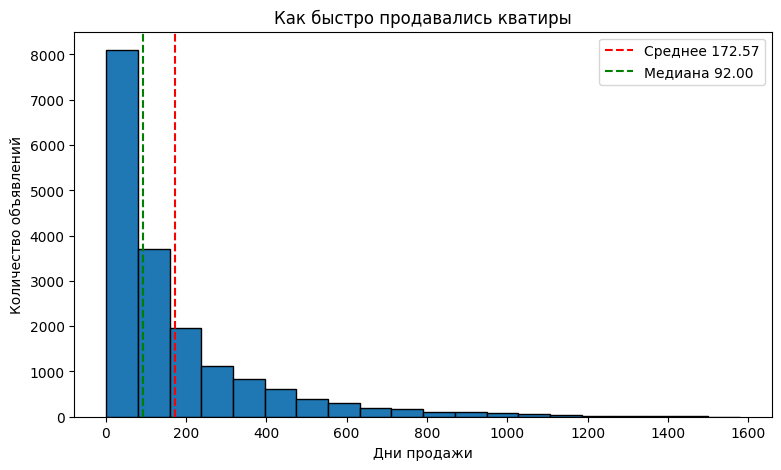

In [111]:
median = df['days_exposition'].median()
mean = df['days_exposition'].mean()

plt.figure(figsize=(9, 5))

plt.hist(df['days_exposition'], bins=20, edgecolor='black')
plt.axvline(mean, color='r', linestyle='--', label=f'Среднее {mean:.2f}')
plt.axvline(median, color='g', linestyle='--', label=f'Медиана {median:.2f}')

plt.legend()
plt.title("Как быстро продавались кватиры")
plt.ylabel("Количество объявлений")
plt.xlabel("Дни продажи")

plt.show()

__Промежуточный вывод__

* среднее количество дней продажи 172
* медианное количество дней продажи 92
* основное распределение между 43 и 220 днями

Объявления, размещённые менее 7 дней, вероятнее всего, ошибочные. Например, клиент мог разместить информацию с ошибкой и тут же убрать, т.к. маловероятно, что квартиру можно продать за 7 дней и менее. Можно, но только знакомым людям, а для этого размещать объявление нет необходимости.

Объявления, размещённые более 200 дней также вызывают опасения, ведь их просто могли забыть снять с публикации. Но и предположение о том, что это нелеквидные квартиры, которые долго продаются, нельзя отсекать.

Изменим масштаб для более детального рассмотрения.

<Axes: >

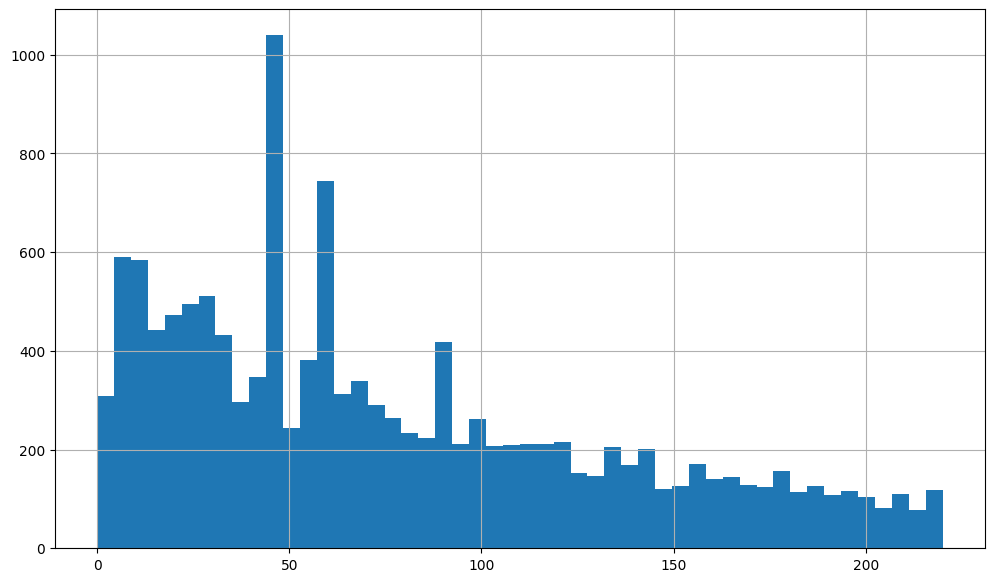

In [112]:
df['days_exposition'].hist(bins=50, range=(0,220), figsize=(12, 7))

__Промежуточный вывод__

* пики на 45, 60 и 90 днях

Изучив информацию по размещению объявлений на площадке Яндекс.Недвижимость, пики соответствуют сроку размещения объявлений, когда они снимаются автоматически.

Чтобы сделать вывод о скорости продажи, построим диаграму размаха.

Text(0.5, 1.0, 'Диаграмма размаха дней рамщений объявлений')

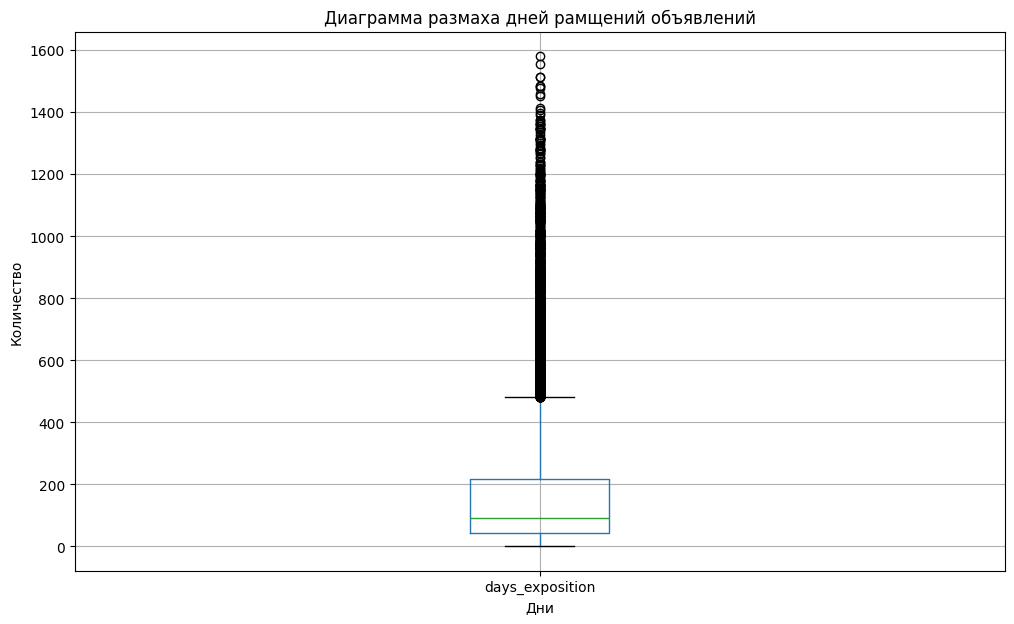

In [113]:
df.boxplot('days_exposition', figsize=(12,7))
plt.xlabel('Дни')
plt.ylabel('Количество')
plt.title('Диаграмма размаха дней рамщений объявлений')

In [114]:
df['days_exposition'].describe()

count    17846.000000
mean       172.568475
std        210.235219
min          1.000000
25%         43.000000
50%         92.000000
75%        218.000000
max       1580.000000
Name: days_exposition, dtype: float64

__Промежуточный вывод__

* необычайно долгие продажи 218 дней и более связаны или с нелеквидной недвижимостью, или с человеческим фактором (забыли снять объявление, происходит автооплата)
* необычайно быстрые продажи сосредоточены до 43 дней - возможно объявление опубликовали с ошибкой и тут же сняли
* можно считать, что средняя продажа происходит от 92 до 172 дней - здесь сосредоточена основная часть выборки

[_назад к ходу исследования_](#research)

[_назад к содержанию_](#content)

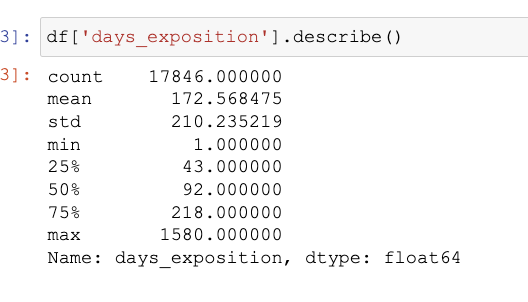

<a class="anchor" id="what_factor"></a>
#### 5.3 Какие факторы больше всего влияют на полную стоимость

Проверим, какие факторы больше всего влияют на конечную стоимость квартир. Для этого построим диаграмы рассеивания, т.к. они поволяют отобразить взаимосвязь, по некоторым признакам датафрейма, а также посмотрим на корреляцию этих признаков.

Text(0.5, 1.0, 'Диаграма зависимости цены от общей площади')

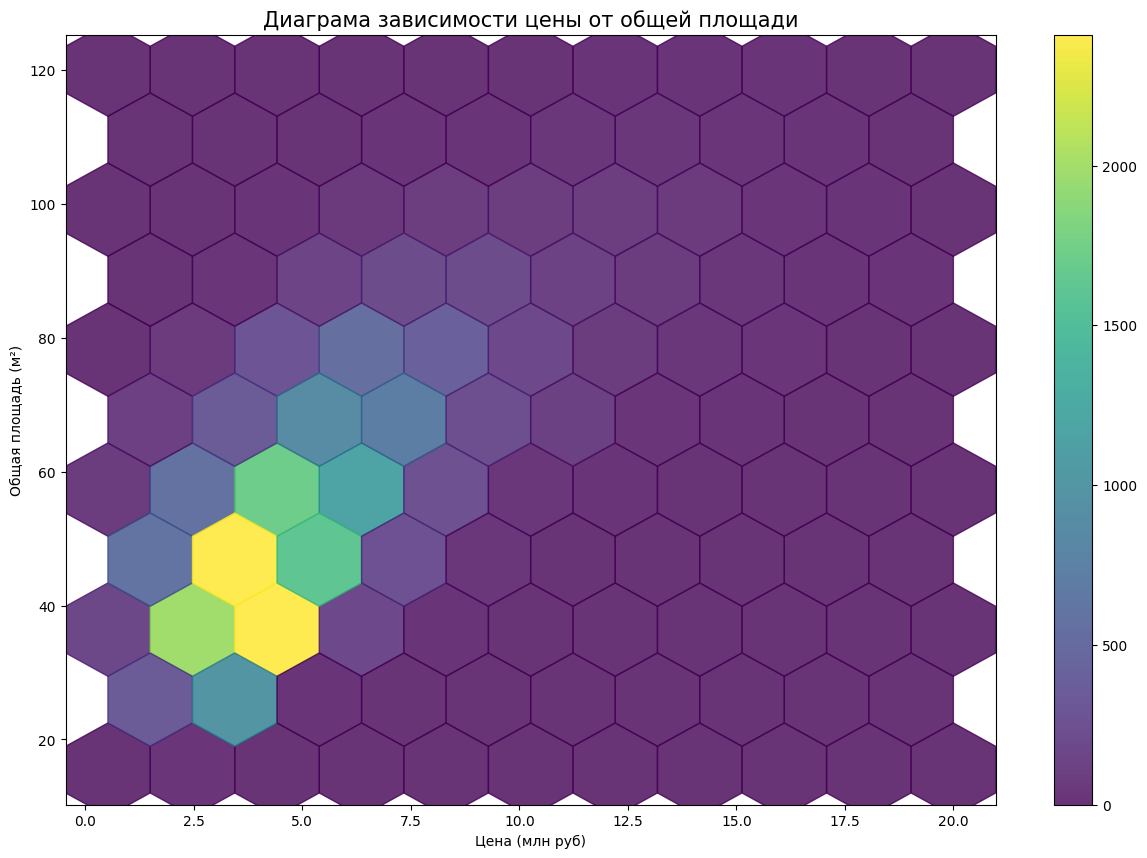

In [115]:
df.plot(
    kind='hexbin', 
    x='last_price_mln', 
    y='total_area', 
    gridsize=10, 
    sharex=False, 
    cmap='viridis', 
    alpha=0.8, 
    figsize=(15, 10)
)

plt.xlabel("Цена (млн руб)", fontsize=10)
plt.ylabel("Общая площадь (м²)", fontsize=10)
plt.title("Диаграма зависимости цены от общей площади", fontsize=15)

In [116]:
print(f"Корреляция: {round(df['last_price_mln'].corr(df['total_area']), 2)}")

Корреляция: 0.71


Мы снова видим самые популярные квартиры - обычно это 40 метровки за 4 млн рублей. Таких объявлений более 2500.

Чем выше площадь, тем дороже квартира, однако объявлений становится меньше.

Положительная линейная корреляция 0.71: с ростом общей площади растёт итоговая стоимость.

<Axes: xlabel='last_price_mln', ylabel='living_area'>

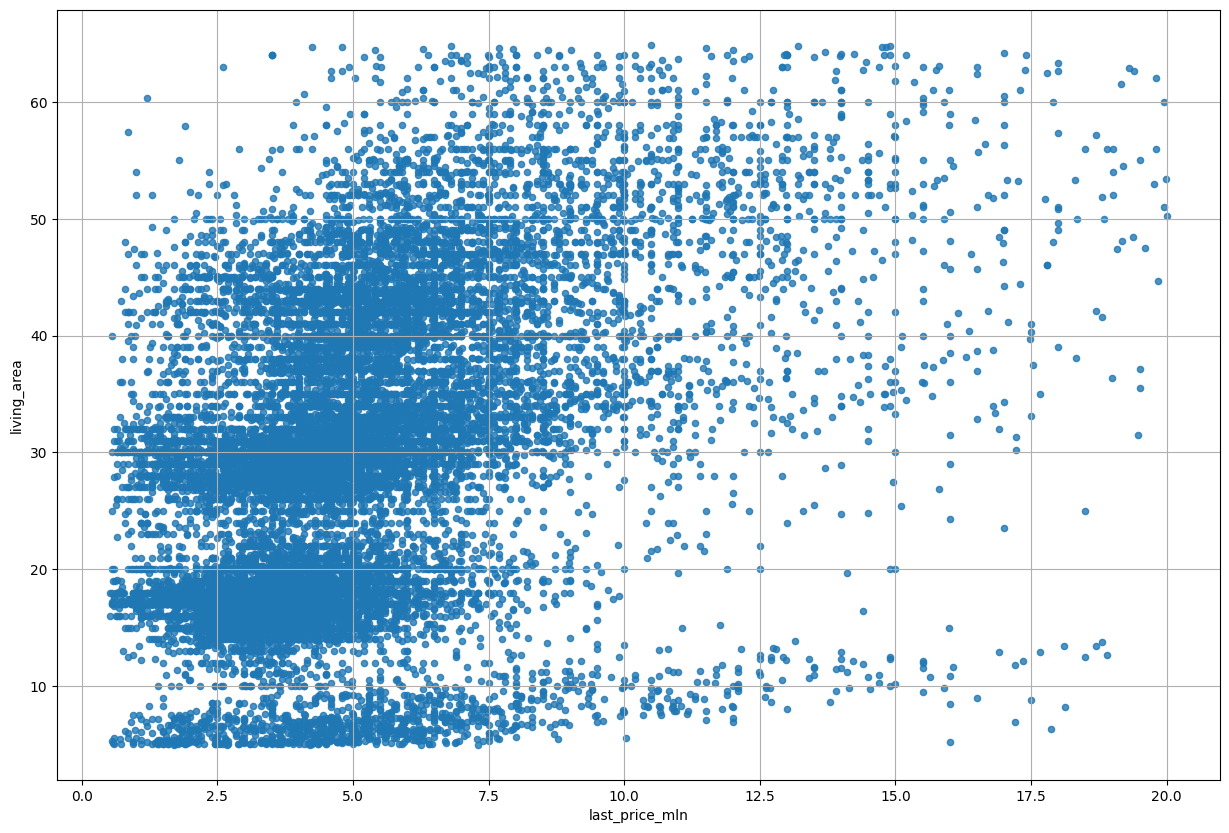

In [117]:
df.plot(
    kind='scatter', 
    x='last_price_mln', 
    y='living_area', 
    sharex=False, 
    alpha=0.8, 
    figsize=(15, 10),
    grid=True,
)

По текущему графику сложно оценить взаимосвязь стоимости и жилой площади. Попробуем сделать сводную таблицу по небольшим группам жилых площадей. 

Text(0.5, 1.0, 'Диаграма зависимости цены от жилой площади')

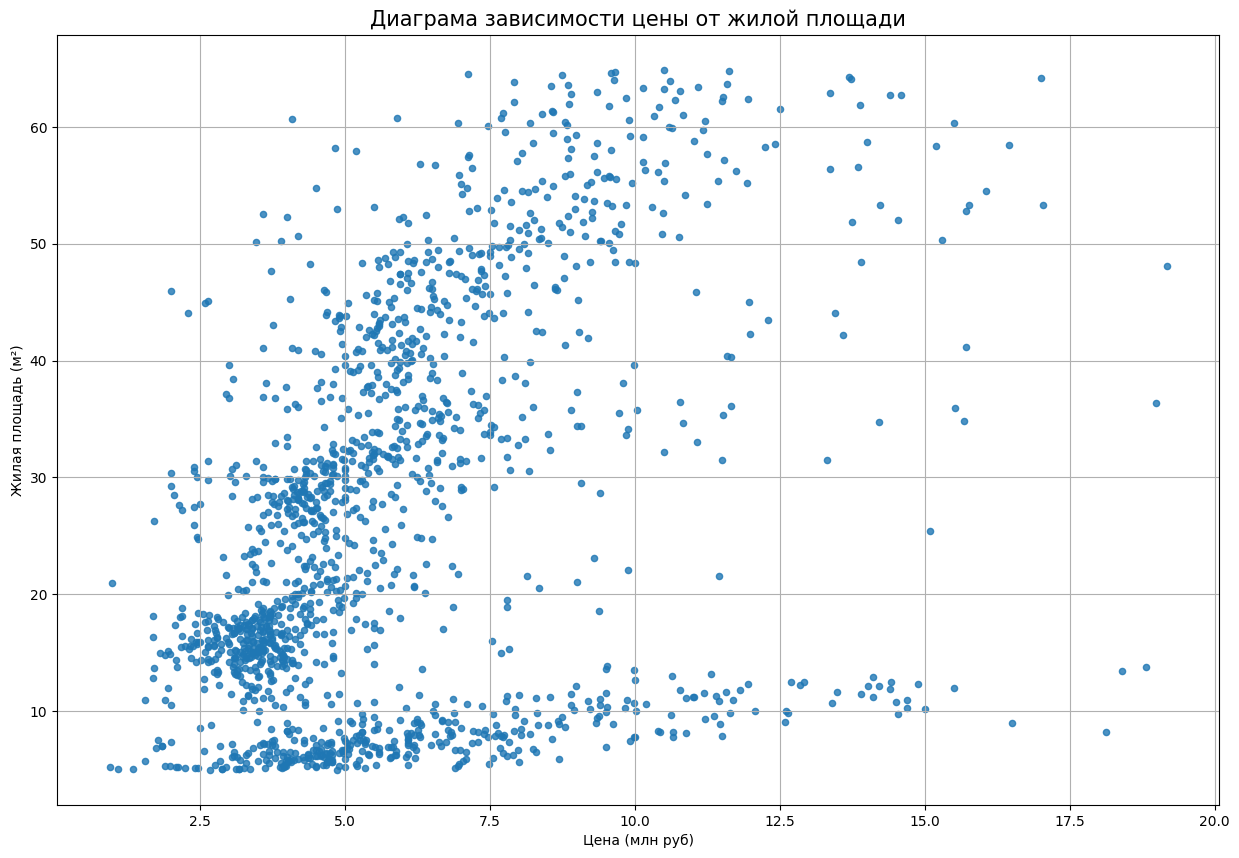

In [118]:
living_area_group = df.pivot_table(index='living_area', values='last_price_mln').reset_index()

living_area_group.plot(
    kind='scatter', 
    x='last_price_mln', 
    y='living_area', 
    alpha=0.8, 
    figsize=(15, 10),
    grid=True,
)

plt.xlabel("Цена (млн руб)", fontsize=10)
plt.ylabel("Жилая площадь (м²)", fontsize=10)
plt.title("Диаграма зависимости цены от жилой площади", fontsize=15)

In [119]:
print(f"Корреляция: {round(df['last_price_mln'].corr(df['living_area']), 2)}")

Корреляция: 0.46


Мы видим, что с ростом жилой площади в половине случаев растёт и стоимость, что логично, однако ещё половина квартир имеют жилую площадь менее 15 м², при этом стоят от 2.5 до 7.5 млн рублей. Уберём эти значения и построим новую диаграму.

<Axes: xlabel='last_price_mln', ylabel='living_area'>

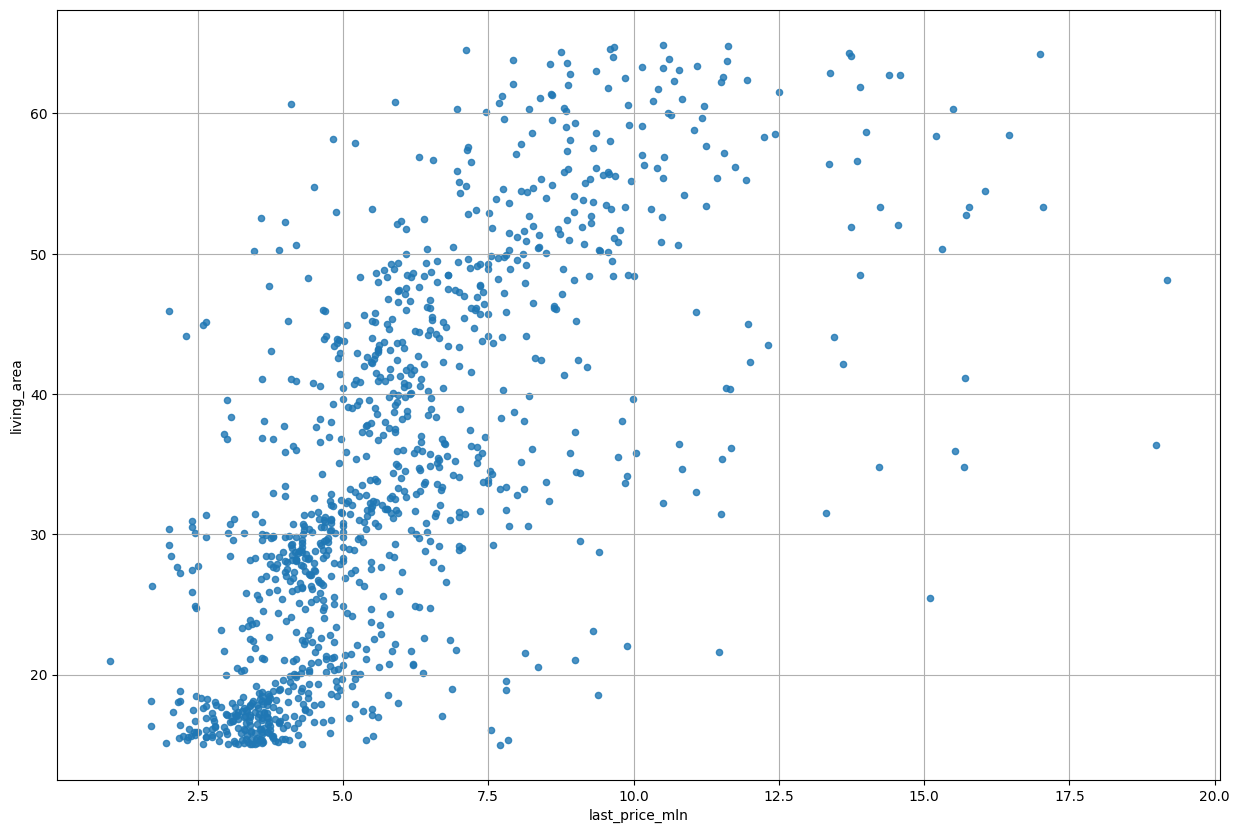

In [120]:
living_area_group.query("living_area > 15").plot(
    kind='scatter', 
    x='last_price_mln', 
    y='living_area', 
    alpha=0.8, 
    figsize=(15, 10),
    grid=True,
)

In [121]:
print(f"Корреляция: {round(living_area_group['last_price_mln'].corr(living_area_group['living_area']), 2)}")

Корреляция: 0.4


Без выбросов корреляция между жилой площадью и общей стоимостью слабая положительная, однако заметно небольшое смещение цены в большую сторону при увеличении жилой площади вплоть до 50 квадратов.

Text(0.5, 1.0, 'Диаграма зависимости цены от площади кухни')

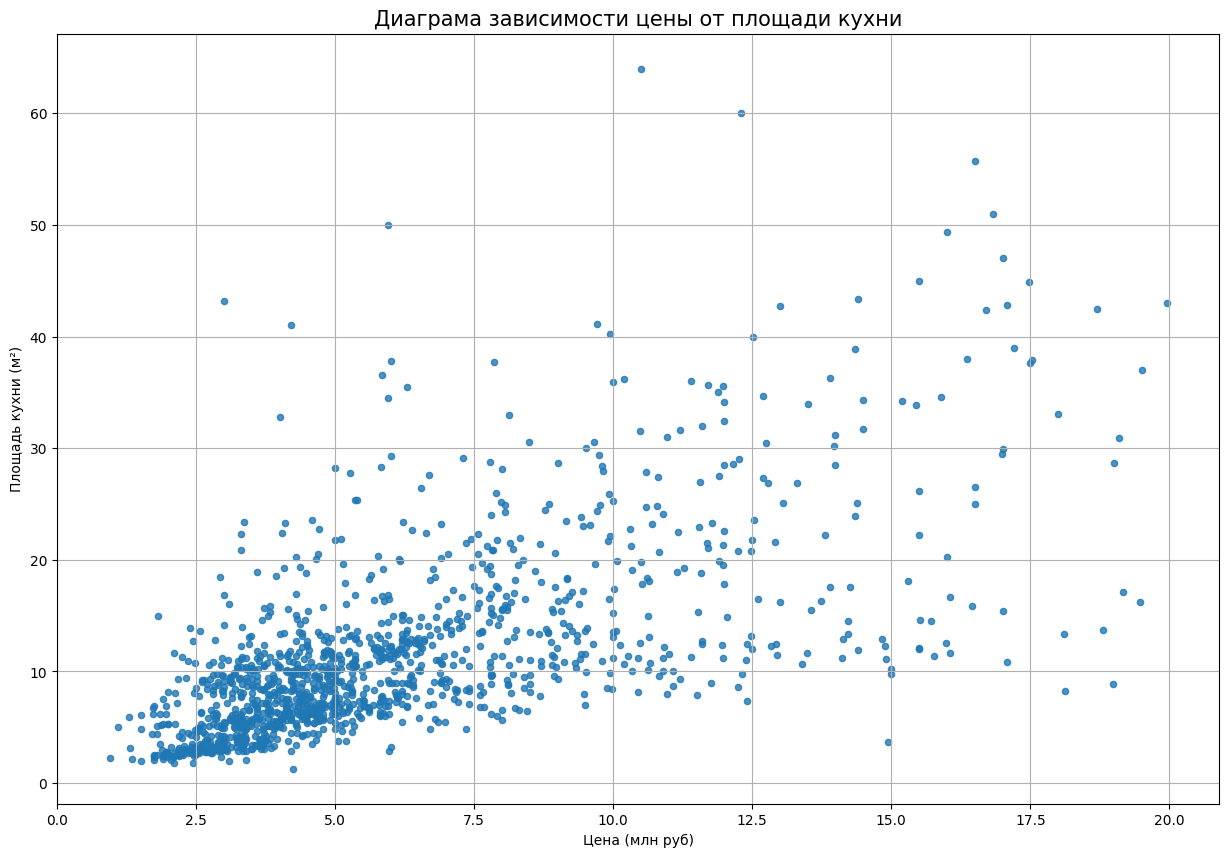

In [122]:
kitchen_area_group = df.pivot_table(index='kitchen_area', values='last_price_mln').reset_index()

kitchen_area_group.plot(
    kind='scatter', 
    x='last_price_mln', 
    y='kitchen_area', 
    alpha=0.8, 
    figsize=(15, 10),
    grid=True,
)


plt.xlabel("Цена (млн руб)", fontsize=10)
plt.ylabel("Площадь кухни (м²)", fontsize=10)
plt.title("Диаграма зависимости цены от площади кухни", fontsize=15)

In [123]:
print(f"Корреляция: {round(kitchen_area_group['last_price_mln'].corr(kitchen_area_group['kitchen_area']), 2)}")

Корреляция: 0.66


Половина квартир с площадью кухни от 2,5 до 12,5 стоят 2.5 - 12.5 млн рублей, однако далее цены сильно разнятся.

Положительная средняя линейная корреляция.

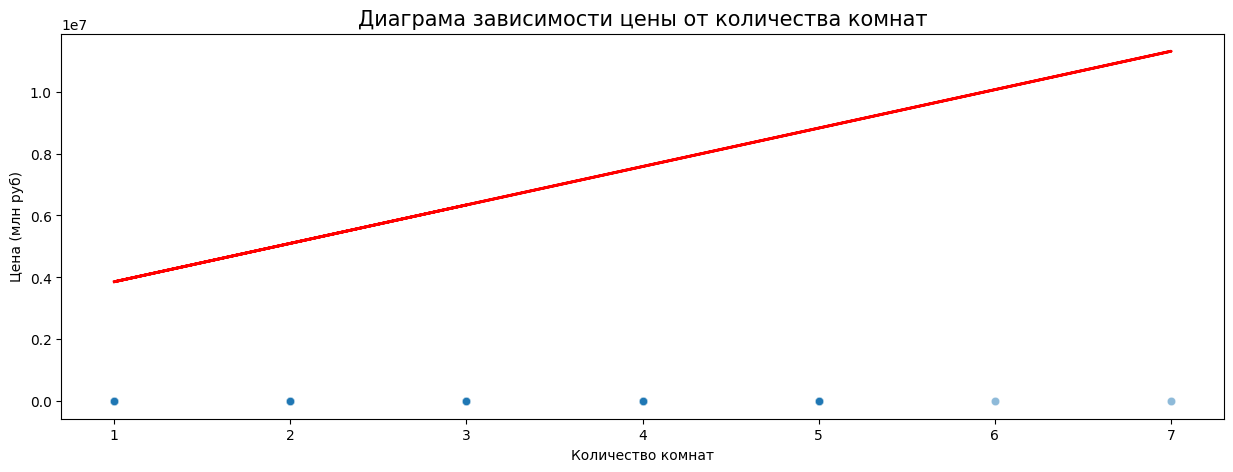

In [124]:
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Создание и обучение модели линейной регрессии
model = LinearRegression()
model.fit(df[['rooms']], df['last_price'])

# Построение графика регрессионной линии
plt.figure(figsize=(15, 5))
sns.scatterplot(x='rooms', y='last_price_mln', data=df, alpha=0.5)
plt.plot(df['rooms'], model.predict(df[['rooms']]), color='red', linewidth=2)

plt.xlabel("Количество комнат", fontsize=10)
plt.ylabel("Цена (млн руб)", fontsize=10)
plt.title("Диаграма зависимости цены от количества комнат", fontsize=15)

plt.show()

In [125]:
print(f"Корреляция: {round(df['last_price_mln'].corr(df['rooms']), 2)}")

Корреляция: 0.4


Коррелиция положительная, но слабая, 0.4. 

Да, с ростом количества комнат растёт и цена, но так бывает не во всех объявлениях.

In [126]:
first_floor_price = df[df['floor'] == 1]['last_price_mln'].mean()
last_floor_price = df[df['floor'] == df['floor'].max()]['last_price_mln'].mean()
other_floor_price = df[(df['floor'] != 1) & (df['floor'] != df['floor'].max())]['last_price_mln'].mean()

print(f"Средняя стоимость квартир на первом этаже: {first_floor_price:.2f} млн")
print(f"Средняя стоимость квартир на последнем этаже: {last_floor_price:.2f} млн")
print(f"Средняя стоимость квартир на других этажах: {other_floor_price:.2f} млн")

Средняя стоимость квартир на первом этаже: 4.10 млн
Средняя стоимость квартир на последнем этаже: 9.90 млн
Средняя стоимость квартир на других этажах: 5.15 млн


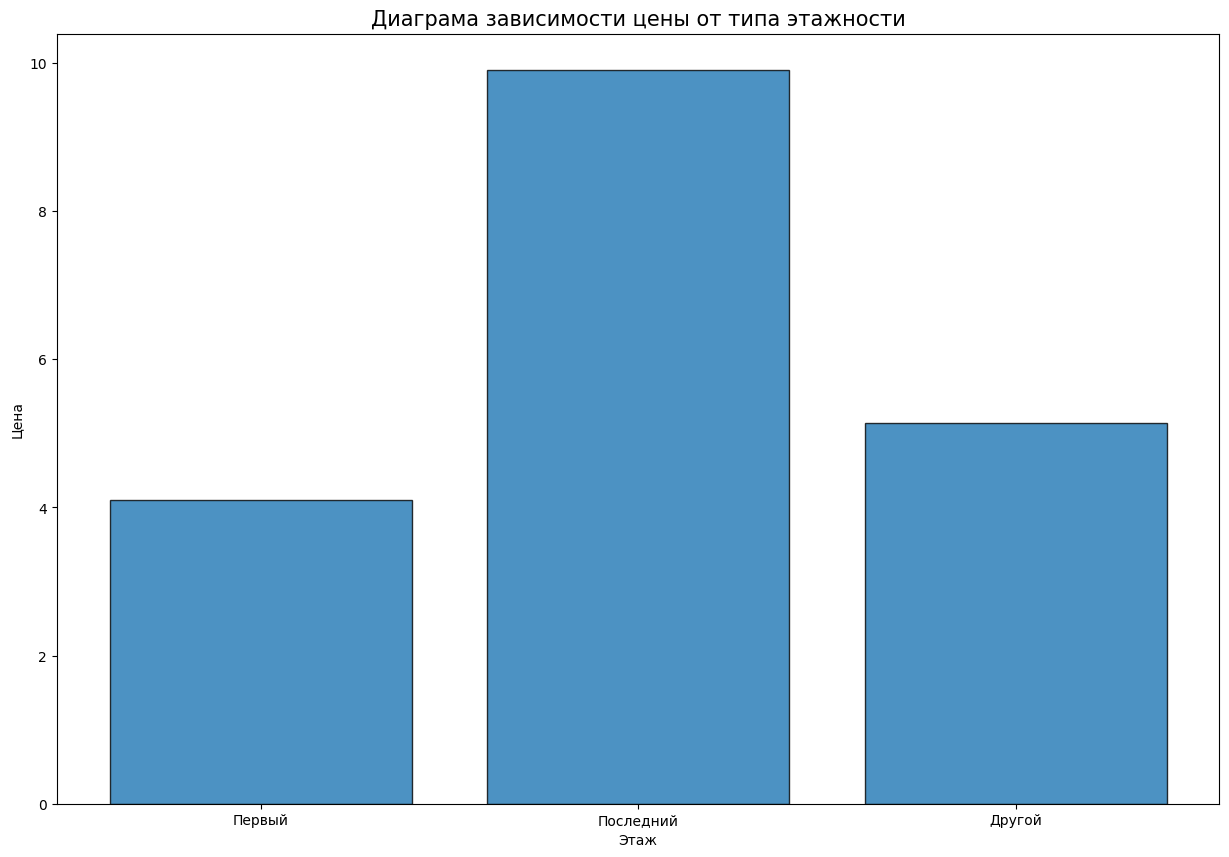

In [127]:
values = [first_floor_price, last_floor_price, other_floor_price]
labels = ['Первый', 'Последний', 'Другой']

plt.figure(figsize=(15, 10))
x = range(len(values))
plt.bar(labels, values, width=0.8, edgecolor='black', alpha=0.8)

plt.title('Диаграма зависимости цены от типа этажности', fontsize=15)
plt.xlabel('Этаж', fontsize=10)
plt.ylabel('Цена', fontsize=10)

plt.show()

В среднем дешевле всего квартиры на первом этаже - это может быть связано с уменьшенной высотой потолков, шумом, отсутствием балконов.

В среднем дороже всего квартиры на последнем этаже (привет, птички и сломанный лифт).

Основная масса квартир, как мы уже выяснили, находится на средних этажах и стоит в районе 5 миллионов - это подтверждает то, что такие квартиры наиболее популярны.

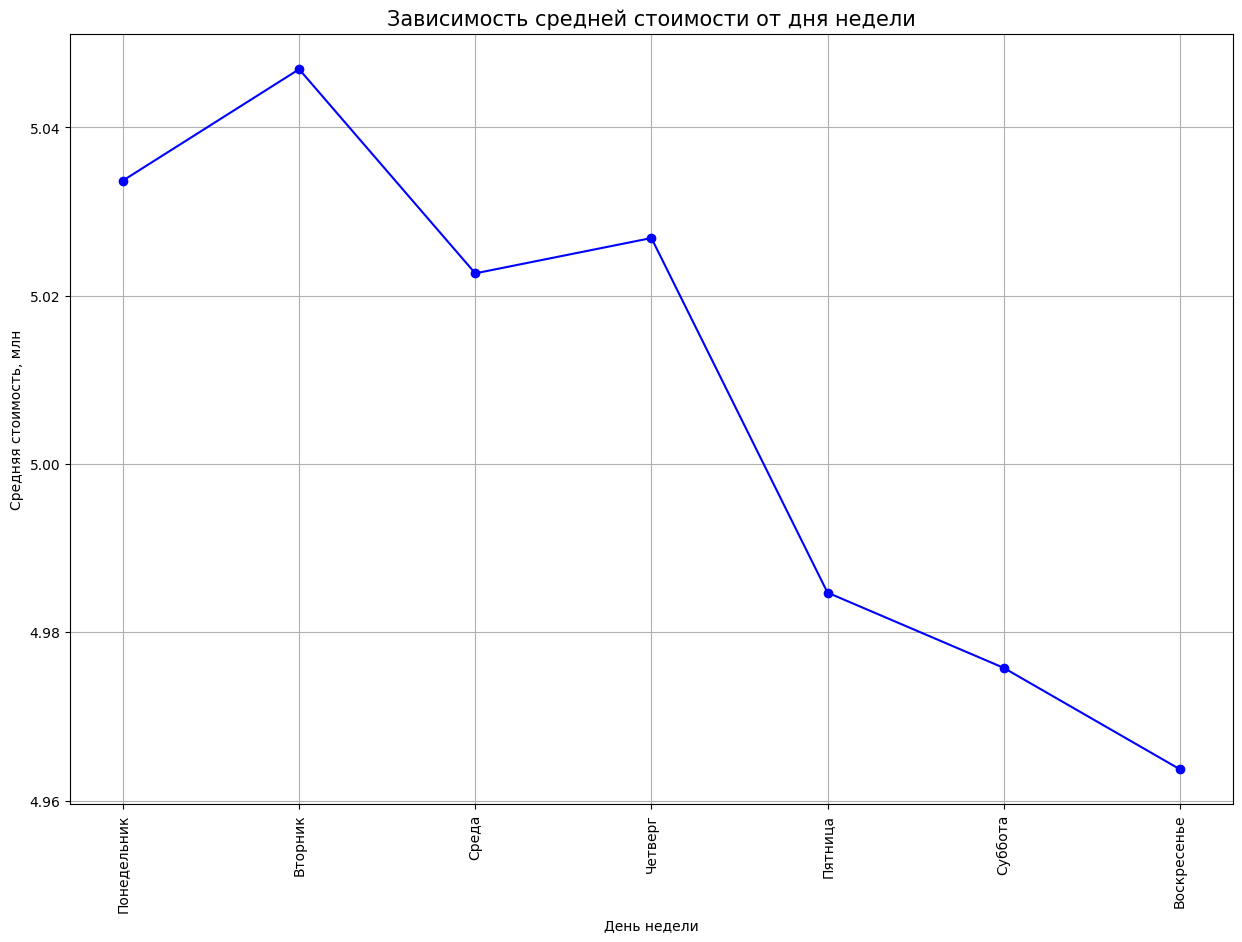

In [128]:
weekday_publicated_group = df.pivot_table(index='weekday_publicated', values='last_price_mln', aggfunc='mean').reset_index()

weekday_names_ru = {
    0: 'Понедельник',
    1: 'Вторник',
    2: 'Среда',
    3: 'Четверг',
    4: 'Пятница',
    5: 'Суббота',
    6: 'Воскресенье'
}

weekday_publicated_group['weekday_publicated'] = weekday_publicated_group['weekday_publicated'].map(weekday_names_ru)

plt.figure(figsize=(15, 10))

plt.plot(
    weekday_publicated_group['weekday_publicated'], 
    weekday_publicated_group['last_price_mln'], 
    marker='o', 
    linestyle='-', 
    color='blue')

plt.grid(True)
plt.title('Зависимость средней стоимости от дня недели', fontsize=15)
plt.xlabel('День недели', fontsize=10)
plt.ylabel('Средняя стоимость, млн', fontsize=10)

plt.xticks(rotation=90)
plt.yticks(fontsize=10)

plt.show()

Самые дорогие объявления размещают по средам, а самые недорогие воскресеньям.

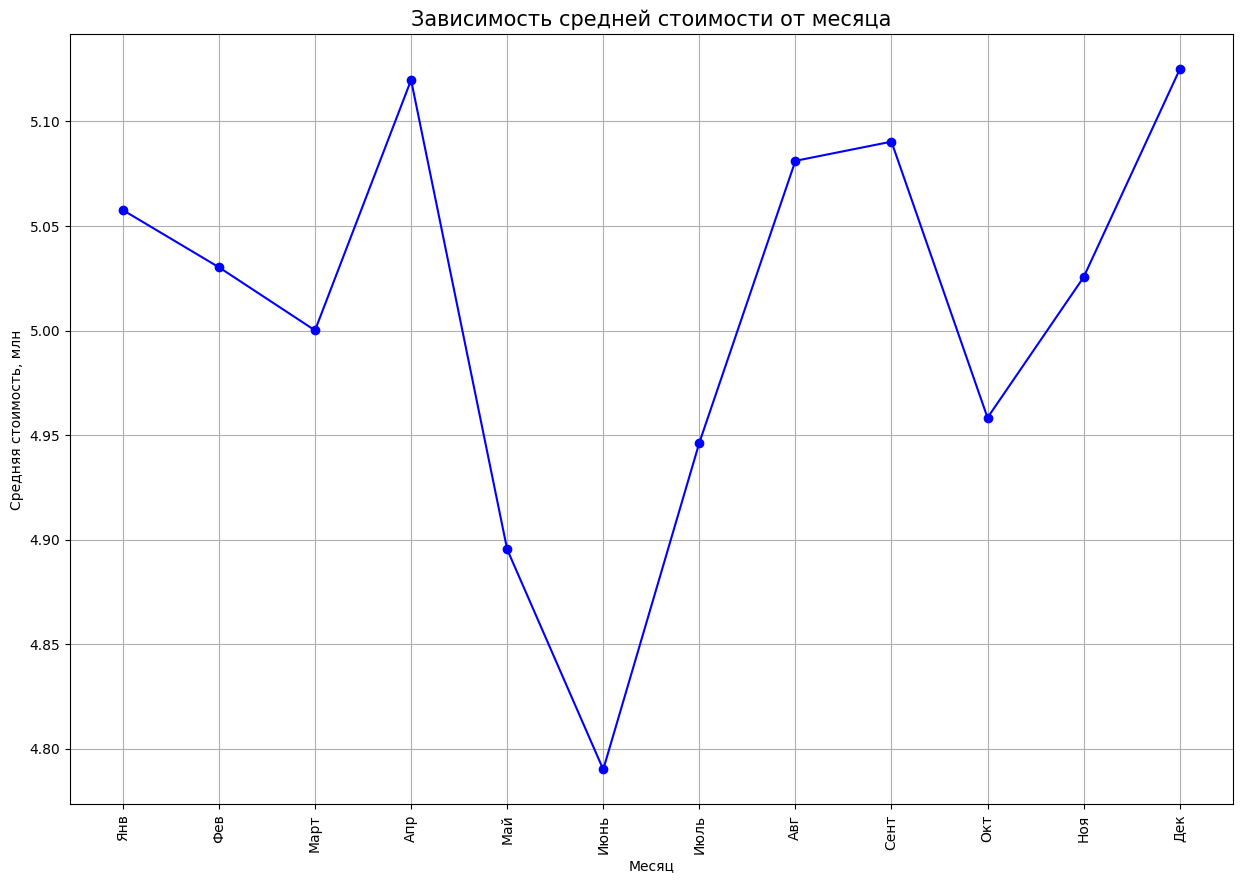

In [129]:
month_publicated_group = df.pivot_table(index='month_publicated', values='last_price_mln', aggfunc='mean').reset_index()

month_names_ru = {
    1: 'Янв',
    2: 'Фев',
    3: 'Март',
    4: 'Апр',
    5: 'Май',
    6: 'Июнь',
    7: 'Июль',
    8: 'Авг',
    9: 'Сент',
    10: 'Окт',
    11: 'Ноя',
    12: 'Дек',
}

month_publicated_group['month_publicated'] = month_publicated_group['month_publicated'].map(lambda name: month_names_ru[name])

plt.figure(figsize=(15, 10))

plt.plot(
    month_publicated_group['month_publicated'], 
    month_publicated_group['last_price_mln'], 
    marker='o', 
    linestyle='-', 
    color='blue'
)

plt.grid(True)
plt.title('Зависимость средней стоимости от месяца', fontsize=15)
plt.xlabel('Месяц', fontsize=10)
plt.ylabel('Средняя стоимость, млн', fontsize=10)

plt.xticks(rotation=90)
plt.yticks(fontsize=10)

plt.show()

В среднем, дешевле всего продают квартиры с мая по июль.

Дороже всего квартиры размещают в апреле. 

Также, начиная с июня, стоимость к концу года растёт.

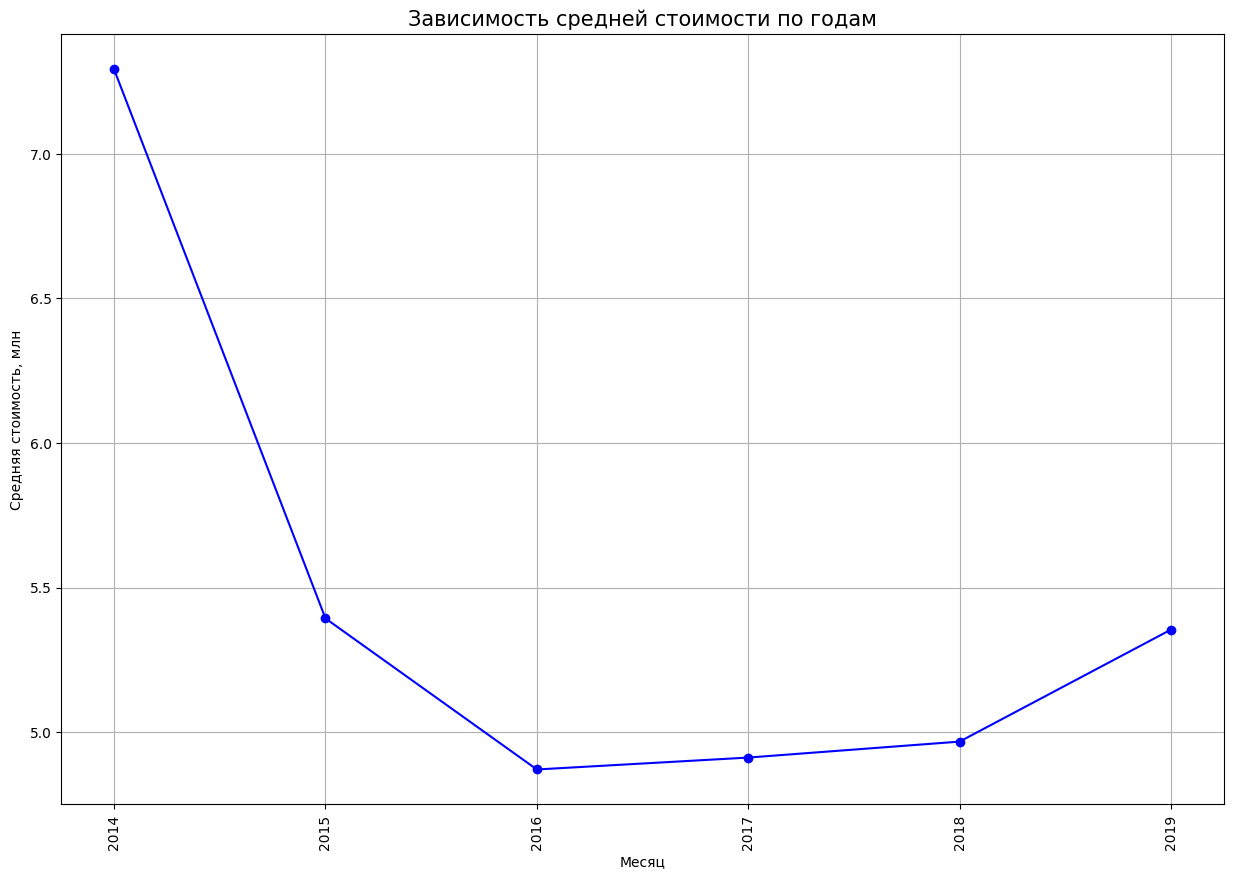

In [130]:
year_publicated_group = df.pivot_table(index='year_publicated', values='last_price_mln', aggfunc='mean').reset_index()


plt.figure(figsize=(15, 10))

plt.plot(
    year_publicated_group['year_publicated'], 
    year_publicated_group['last_price_mln'], 
    marker='o', 
    linestyle='-', 
    color='blue')

plt.grid(True)
plt.title('Зависимость средней стоимости по годам', fontsize=15)
plt.xlabel('Месяц', fontsize=10)
plt.ylabel('Средняя стоимость, млн', fontsize=10)

plt.xticks(rotation=90)
plt.yticks(fontsize=10)

plt.show()

В 2014 году, как мы помним, объявлений было не так много, однако средняя стоимость наивысшая - более 6,6 миллионов рублей. Зетем, к 2015 году стоимость резко упала до 5,20 миллионов.

Возможно, упала не столько цена, сколько площадь продаваемых квартир.

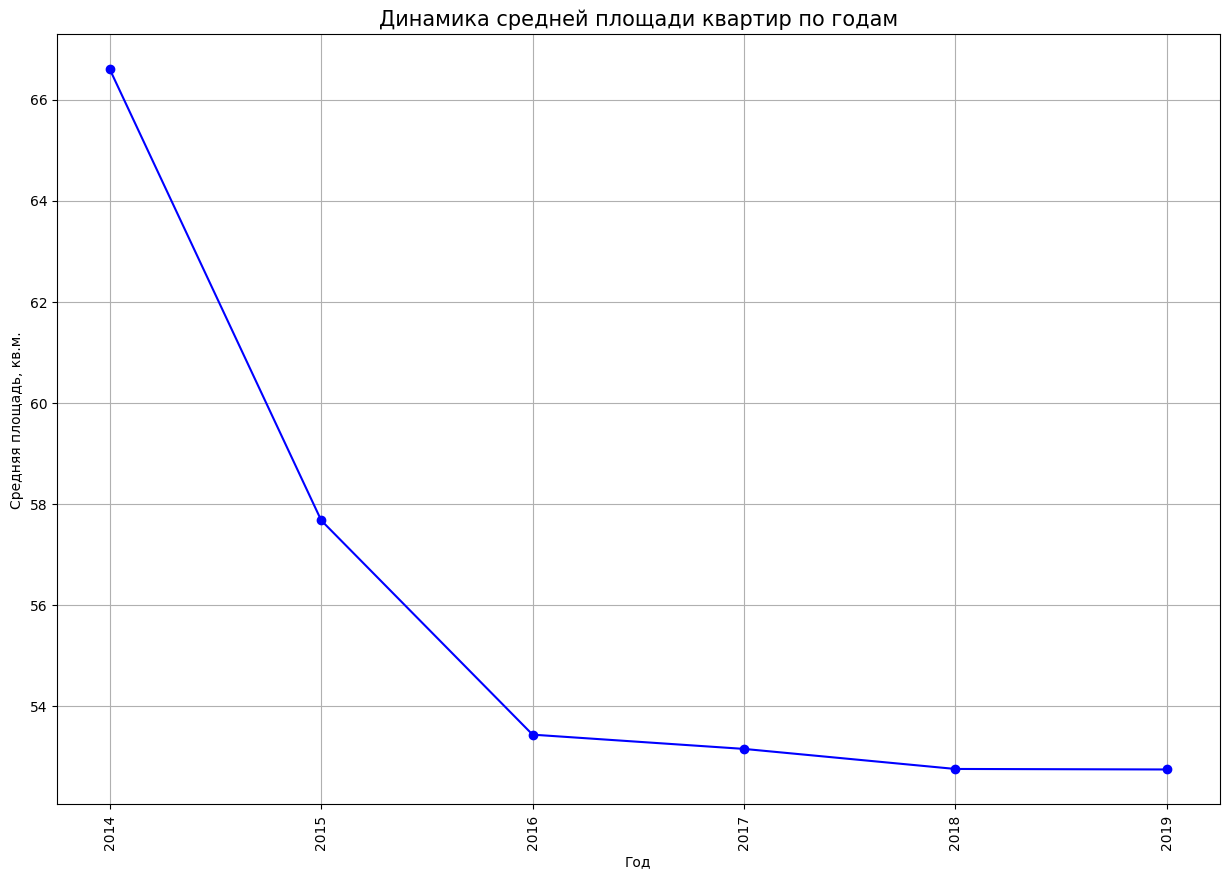

In [131]:
total_area_group_to_year = df.pivot_table(index='year_publicated', values='total_area', aggfunc='mean').reset_index()


plt.figure(figsize=(15, 10))

plt.plot(
    total_area_group_to_year['year_publicated'], 
    total_area_group_to_year['total_area'], 
    marker='o', 
    linestyle='-', 
    color='blue')

plt.grid(True)
plt.title('Динамика средней площади квартир по годам', fontsize=15)
plt.xlabel('Год', fontsize=10)
plt.ylabel('Средняя площадь, кв.м.', fontsize=10)

plt.xticks(rotation=90)
plt.yticks(fontsize=10)

plt.show()

Действительно, средняя стоимость квартир упала не из-за отсуствия спроса, а из-за уменьшения площади продаваемых квартир из года в год.

__Промежуточный вывод__

Больше всего на стоимость квартир влияет общая площадь (частично жилая и кухонная).
С ростом числа комнат квартира становится несколько дороже, но себестоимость, наоборот, уменьшается.

Дороже всего покупать квартиру с несколькими комнатами на последнем этаже в апреле в среду или четверг.

Дешевле всего покупать однокомнатную квартиру на 1 этаже в пятницу в мае или июне.

Явная зависимость от года размещения отсутствует.

Чаще всего стали продавать небольшие недорогие квартиры.

[_назад к ходу исследования_](#research)

[_назад к содержанию_](#content)

<a class="anchor" id="top_10"></a>
#### 5.4 ТОП-10 населённых пунктов c самой высокой и низской стоимостью квадратного метра

Посчитайте среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений и найдём локацию самого дорогого и недорого.

In [132]:
top_cities_ads = df.pivot_table(
    index='locality_name', 
    values='price_sqr_m', 
    aggfunc={'price_sqr_m': ['count', 'mean']}
    ).sort_values(by='count', 
                  ascending=False
    ).reset_index()

top_cities_ads.columns = ['location', 'count', 'avg_price_to_sqr_metr']
display(top_cities_ads.head(10))


# самый дорогой и дешевый квадрат без учёта кол-ва объявлений
max_price = top_cities_ads['avg_price_to_sqr_metr'].max()
min_price = top_cities_ads['avg_price_to_sqr_metr'].min()

most_expensive_city = top_cities_ads.query("avg_price_to_sqr_metr == @max_price")['location']
most_cheapest_city = top_cities_ads.query("avg_price_to_sqr_metr == @min_price")['location']

,location,count,avg_price_to_sqr_metr
0,Санкт-Петербург,12970,107891.901542
1,Посёлок Мурино,515,85614.728155
2,Посёлок Шушары,422,78448.260664
3,Всеволожск,378,67073.730159
4,Пушкин,324,101509.179012
5,Колпино,322,75409.319876
6,Посёлок Парголово,315,90113.380952
7,Гатчина,292,68420.938356
8,Деревня Кудрово,282,92316.187943
9,Выборг,200,57522.470000


__Промежуточный вывод__

Самый дорогой средний квадратный метр с учётом количества объявлений стоит 106961 тысяч рублей ожидаемо в центре области - Санкт-Петербурге.

Самая недорогая стоимость квадратного метра в Петергофе.

[_назад к ходу исследования_](#research)

[_назад к содержанию_](#content)

<a class="anchor" id="how_nearest"></a>
#### 5.5 Как стоимость квадратного метра зависит от удалённости от центра Питера

np.float64(-0.8816158942572973)

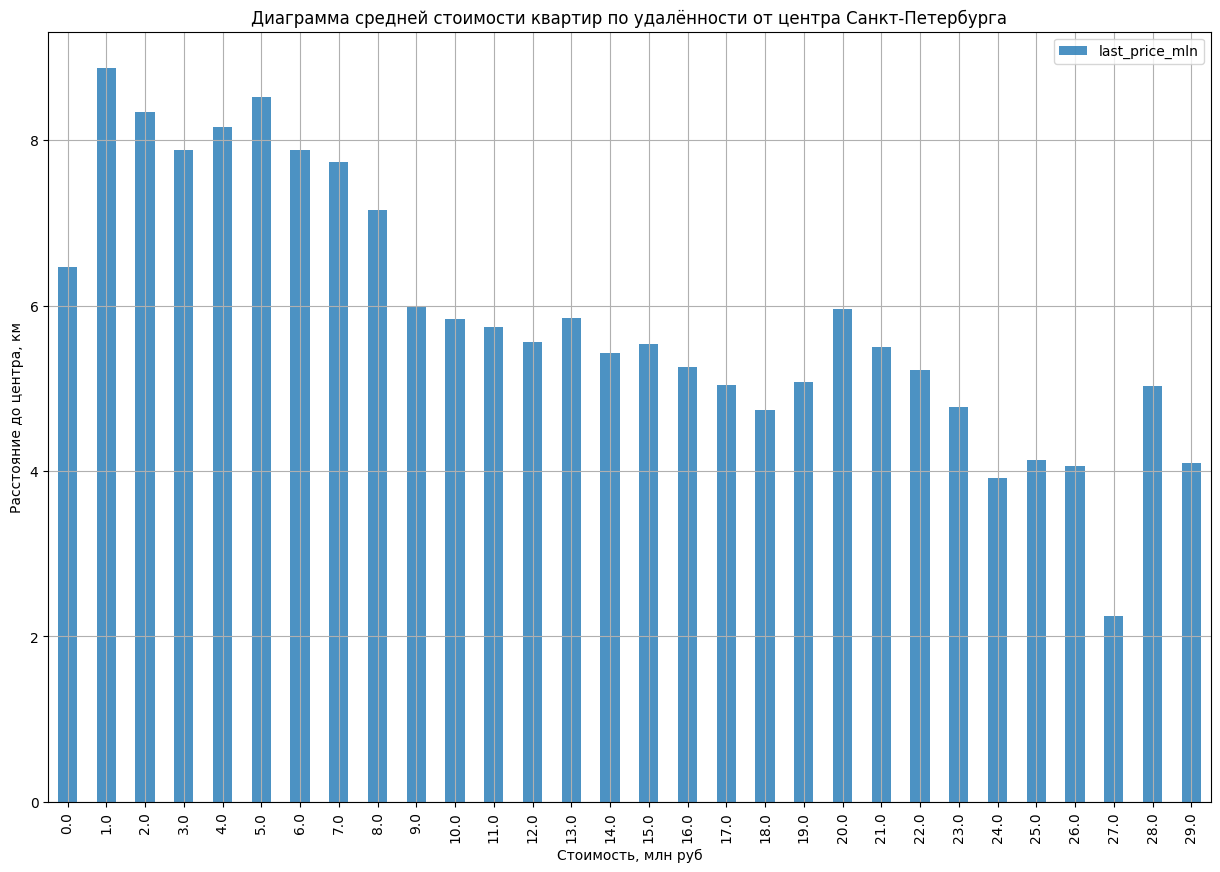

In [133]:
spb_center = df[df['locality_name'] == 'Санкт-Петербург']
group_distance_spb = spb_center.pivot_table(index='distance_do_center_km', values='last_price_mln').reset_index()

group_distance_spb.plot(
    kind='bar',
    x='distance_do_center_km',
    y='last_price_mln',
    alpha=0.8, 
    figsize=(15, 10),
    grid=True,
    title='Диаграмма средней стоимости квартир по удалённости от центра Санкт-Петербурга',
    xlabel='Стоимость, млн руб',
    ylabel='Расстояние до центра, км'
)

group_distance_spb['distance_do_center_km'].corr(group_distance_spb['last_price_mln'])

__Промежуточный вывод__

Существует линейная отрицательная корреляция между расстоянием от центра и средней стоимостью.

Так, чем ближе квартира к центру Санкт-Петербурга, тем дороже.

[_назад к ходу исследования_](#research)

[_назад к содержанию_](#content)

<a class="anchor" id="result"></a>
### 7. Результаты исследования

**Мы получили и выполниили предобработку данных**
* удалили или заполнили пропуски, не трогая картографические данные
* удалили или исправили нехарактерные значения
* проверили явные и неявные дубликаты
* изменили типы данных некоторых столбцов

От изначального датафрейма для анализа осталось 86%.

**Рассчитали и добавили новые признаки с целью улучшения качества исследовательского анализа**

* цена одного квадратного метра
* день, месяц и год публикации объявления
* тип этажа (первый, последний или другой)
* расстояние до центра в киллометрах


**Изученили общие признаки и построили гистограммы**

Наибольшее количество предложений квартир на площадке по Ленинградской области обладают следующими признаками:

* общая площадь от 30 до 70 квадратов с пиком в 40, жилая 19 квадратов и площадь кухни 6 квадратов
* стоят 2,5-7,5 млн руб
* находятся в пятиэтажках
* на 2-4 этажах с 1-2 комнатами
* с высотой потолков 2,65
* с расстоянием до центра Санкт-Петербурга 15 км и 28 км до ближайшего аэропорта
* рядом есть парки (400-500 метров)

Наименьшее количество предложений квартир на площадке по Ленинградской области обладают следующими признаками:

* более 40 квадратов
* находятся на последних этажах с 3-4 комнатами
* стоят дороже 7,5 млн руб

**Общие наблюдения:**

Начичая с 2014 рынок онлайн-площадки только начал формироваться. Сначала начали продавать дорогие и большие квартиры, а затем произошёл резкий спад в сторону недорогих и небольших квартир, тендеция сохраняется.


| Год | Скорость продажи, дни | Количество объявлений, шт |
| --- | --- | --- |
| 2014 | 939| 82 |
| 2015 | 629 | 901 |
| 2016 | 314 | 2310 |
| 2017 | 153 | 6944 |
| 2018 | 93 | 6631 |
| 2019 | 31 | 978 |

2017 и 2018 год являлся самым прибыльным, т.к. прозошёл резкий рост кол-ва объявлений, а срок продажи, наоборот, сократился с 939 до 153 и 93 дней.

### Ответы на задачи исследования

1. Как быстро продавались квартиры?

* продать квартиру через сервис можно за 31-172 дней в зависимости от её характеристик
* впротивном случае, срок врьируется от 7 до 600 дней.

2. Какие факторы больше всего влияют на полную стоимость?

* больше всего на стоимость квартир влияет общая площадь (как следствие, жилая и площадь кухни).
* дороже всего можно купить квартиру с несколькими комнатами на последнем этаже в апреле, августе, сентябре и декабре, в среду или четверг.
* дешевле можно купить однокомнатную или двухкомнатную квартиру (от 40 квадратов) на 1 этаже в пятницу в мае или июне.

3. ТОП-10 населённых пунктов c самой высокой и низской стоимостью квадратного метра?

- Санкт-Петербург - 106961 рублей за квадратный метр
- Посёлок Мурино - 85318 рублей за квадратный метр
- Посёлок Шушары - 78155 рублей за квадратный метр
- Всеволожск - 67115 рублей за квадратный метр
- Колпино - 75348 рублей за квадратный метр
- Пушкин - 100737 рублей за квадратный метр
- Гатчина - 68330 рублей за квадратный метр
- Посёлок Парголово - 92931 рублей за квадратный метр
- Деревня Кудрово - 92547 рублей за квадратный метр
- Петергоф - 83259 рублей за квадратный метр

4. Как стоимость квадратного метра зависит от удалённости от центра Питера?

* чем ближе центр города, тем дороже стоит квадратный метр.

### Рекомендации

* для застройщиков: строить 1-2 комнатные квартиры рядом с парком и центром Санкт-Петербурга
* для площадики объявлений: проверить, с чем связано резкое снижение кол-ва объявлений при росте скорости продажи; повысить комиссию за 1 и 2-комнатные квартиры площадью 30-70 квадратов в апреле, августе, сентябре и декабре, т.к. рекломадатель указывает большую общую стоимость и, соответственно, получает за квартиру больше денег
* для покупателей: приобретать квартиру на 1 этаже в мае или июне по площади 40 квадратов - много предложений и невысокая цена


[_назад к содержанию_](#content)

<a class="anchor" id="func"></a>

In [134]:
def generate_column_description(df):
    """
    Генерирует описание каждого столбца в DataFrame: наименование, доля пропусков, уникальные значения, 
    и статистические характеристики столбца

    Parameters:
    df (pandas.DataFrame): DataFrame, для которого требуется сгенерировать описание столбцов.

    Returns:
    None
    """
    for column in df.columns:
        create_cell(analyze_column(df, column))
        create_cell(text="Обнаружены аномалии:\n\nВозможные причины:\n\nЧто решено сделать:")

        
def analyze_column(df, column):
    """
    Анализирует столбец DataFrame и формирует его заданное описание.

    Parameters:
    df (pandas.DataFrame): DataFrame, содержащий анализируемый столбец.
    column (str): Название анализируемого столбца.

    Returns:
    str: Строка с описанием анализируемого столбца.
    """
    unique_values = df[column].unique()
    value_counts = df[column].value_counts(sort=True)
    part_skip = df[column].isna().mean().round(2)
    
    result = []
    result.append(f"**Столбец:**\n\n <span style='color:blue'>{column}</span>")
    result.append(f"**Доля пропусков:**\n\n {part_skip}")
    result.append(f"**Уникальные значения:**\n\n {unique_values}")

    
    if df[column].dtype in ['int64', 'float64']:
        description = df[column].describe()
        result.append(f"**Характеристики значений:**")
        result.append(f"count {description['count']}")
        result.append(f"min {description['min']}")
        result.append(f"25% {description['25%']}")
        result.append(f"median {description['50%']}")
        result.append(f"75% {description['75%']}")
        result.append(f"max {description['max']}")
    else:
        result.append(f"Статистические характеристики не определены.")
    
    return "\n\n".join(result)


def create_cell(text):
    """
    Выводит текст в виде ячейки Markdown.

    Parameters:
    text (str): Текст, который требуется вывести в ячейке.

    Returns:
    None
    """
    display(Markdown(text))


# generate_column_description(df)

[_назад к содержанию_](#content)